# Labellisez et appliquez des approches semi-supervisées en traitement d'images médicales

In [1]:
# Permet de manipuler les chemins de fichiers de manière indépendante du système d'exploitation
from pathlib import Path

# Permet de charger des jeux de données d'images organisés en dossiers
from torchvision.datasets import ImageFolder

# Contient les transformations à appliquer aux images, et les models préentrainés comme resnet
from torchvision import transforms, models

# Permet de lire directement une image au format Tensor
from torchvision.io import read_image

# Bibliothèque pour l'affichage des graphiques et des images, et visualisation.
import matplotlib.pyplot as plt
import seaborn as sns


# Bibliothèque de calcul scientifique
import numpy as np

# Bibliothèque de manipulation de tableaux de données
import pandas as pd

# Bibliothèque principale de deep learning
import torch

# Barre de progression lors du traitement des images
from tqdm import tqdm

# Standardisation des données
from sklearn.preprocessing import StandardScaler


# Réduction dimensionnelle
from sklearn.decomposition import PCA


# Algorithmes de clustering
from sklearn.cluster import KMeans, DBSCAN


# Métrique d'évaluation
from sklearn.metrics import adjusted_rand_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Import de la fonction permettant de séparer les données
from sklearn.model_selection import train_test_split

# Import de la classe Dataset de PyTorch
from torch.utils.data import Dataset, DataLoader

# Lecture des images avec Pillow
from PIL import Image

# Permet de calculer la distance au k-ième plus proche voisin (utile pour choisir eps de DBSCAN)
from sklearn.neighbors import NearestNeighbors

import cv2

## 1. Exploration du jeu de données

In [2]:
# Chemin vers le dossier principal contenant les données
DATA_DIR = Path("mri_dataset_brain_cancer_oc")

In [3]:
# Affichage de l'organisation du dataset
for dossier in DATA_DIR.iterdir():
    print(dossier)

mri_dataset_brain_cancer_oc/sans_label
mri_dataset_brain_cancer_oc/Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt
mri_dataset_brain_cancer_oc/avec_labels


In [4]:
# Vérification du contenu du dossier avec labels
for dossier in (DATA_DIR / "avec_labels").iterdir():
    print(dossier)

mri_dataset_brain_cancer_oc/avec_labels/cancer
mri_dataset_brain_cancer_oc/avec_labels/normal


On dispose d'un fichier sans_label, et d'un fichier avec_labels lui même divisé en deux fichier cancer et normal.

On charge les données labellisées

In [5]:
# Transformation appliquée aux images
transform = transforms.Compose([transforms.ToTensor()]) # ToTensor() convertit automatiquement :une image PNG en tenseur PyTorch et normalise les pixels entre 0 et 1.

# Chargement des images labellisées
# ImageFolder :parcourt automatiquement les sous-dossiers attribue un label numérique à chaque dossier Ici il détectera automatiquement :cancer  -> 0, normal  -> 1
labeled_dataset = ImageFolder(root=DATA_DIR / "avec_labels", transform=transform)

# Nombre total d'images labellisées
print("Nombre d'images :", len(labeled_dataset))

# Nom des classes
print("Classes :", labeled_dataset.classes)

# Correspondance classe -> entier
print("Labels :", labeled_dataset.class_to_idx)

Nombre d'images : 100
Classes : ['cancer', 'normal']
Labels : {'cancer': 0, 'normal': 1}


On charge les images non labellisées

In [6]:
# Liste de toutes les images PNG
# Le dossier sans_label ne contient qu'un seul dossier. On récupère donc simplement la liste des images.
unlabeled_images = list((DATA_DIR / "sans_label").glob("*.jpg")) # glob("*.png") recherche tous les fichiers PNG.

# Nombre d'images
print("Nombre d'images non labellisées :", len(unlabeled_images))

Nombre d'images non labellisées : 1406


In [7]:
# Lecture de la première image
image = read_image(str(unlabeled_images[0])) # read_image() lit directement une image et renvoie un Tenseur pytorch
print(image.shape) # Cela signifie 3 canaux (RGB), hauteur = 512, largeur = 512

torch.Size([3, 512, 512])


In [8]:
print(image.shape)

torch.Size([3, 512, 512])


Affichons l'image en question.

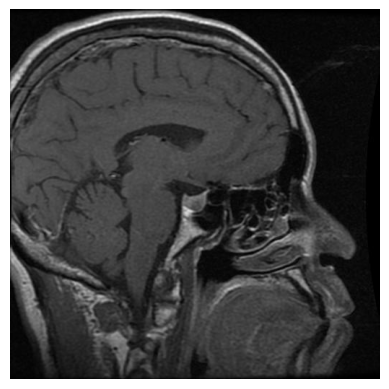

In [9]:
# Les tenseurs PyTorch sont stockés sous la forme (C, H, W) alors que Matplotlib attend (H, W, C), il faut donc permuter les axes.
plt.imshow(image.permute(1, 2, 0))

plt.axis("off")

plt.show()

Affichons plusieurs images.

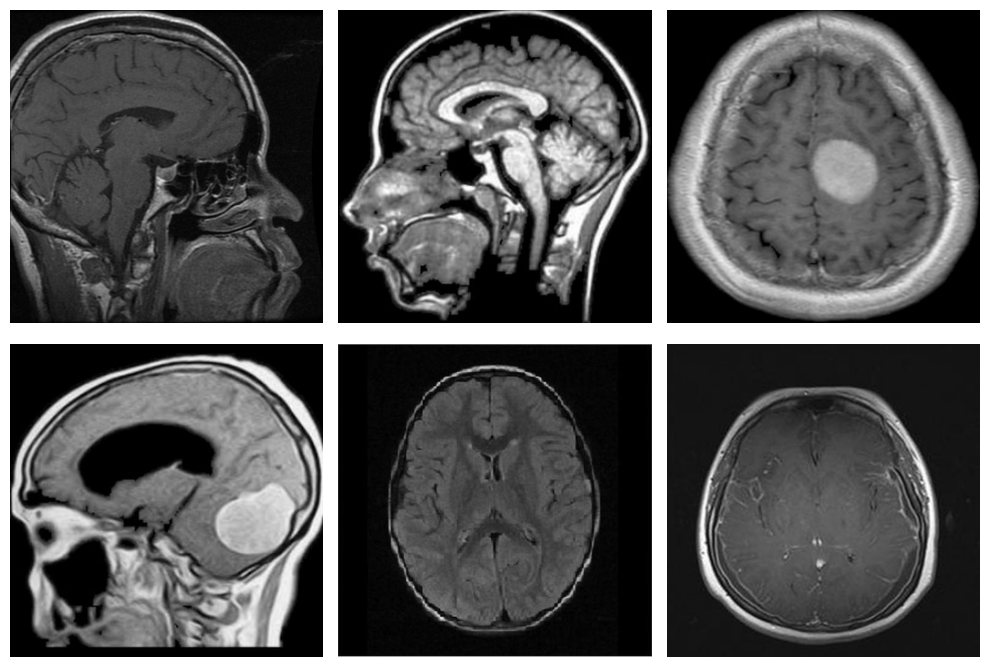

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for ax, img_path in zip(axes.ravel(), unlabeled_images[:6]):

    img = read_image(str(img_path))

    ax.imshow(img.permute(1, 2, 0))

    ax.axis("off")

plt.tight_layout()

plt.show()

Verifions la taille des images.

In [11]:
sizes = []

for img_path in unlabeled_images:

    img = read_image(str(img_path))

    sizes.append((img.shape[1], img.shape[2]))

print("Nombre de résolutions différentes :", len(set(sizes)))

Nombre de résolutions différentes : 1


Toutes les images ont la même résolution.

Vérifions les canaux.

In [12]:
channels = []

for img_path in unlabeled_images:

    img = read_image(str(img_path))

    channels.append(img.shape[0])

print(np.unique(channels))

[3]


Toutes les images sont en RGB.

Les images porraient être des images en niveaux de gris stockées au format RGB. Si tel est le cas Les niveaus de RGB doivent être sensiblement identiques.

In [13]:
all_same_channels = True

for img_path in unlabeled_images:

    img = read_image(str(img_path))

    r = img[0]
    g = img[1]
    b = img[2]

    if not (torch.equal(r, g) and torch.equal(r, b) and torch.equal(g, b)):
        all_same_channels = False
        break  # inutile de continuer dès qu'une image ne correspond pas

if all_same_channels:
    print("OK : toutes les images ont les mêmes valeurs RGB")
else:
    print("Attention : au moins une image possède des canaux RGB différents")

Attention : au moins une image possède des canaux RGB différents


In [14]:
different_channels = []

for img_path in unlabeled_images:

    img = read_image(str(img_path))

    r = img[0]
    g = img[1]
    b = img[2]

    if not (torch.equal(r, g) and torch.equal(r, b) and torch.equal(g, b)):
        different_channels.append(img_path)

print("Nombre d'images avec RGB différents :", len(different_channels))
print("Nombre total d'images :", len(unlabeled_images))

Nombre d'images avec RGB différents : 9
Nombre total d'images : 1406


On a peu d'images avec des niveaux de RGB différents

In [15]:
channel_differences = []

for img_path in unlabeled_images:

    img = read_image(str(img_path)).float()

    r = img[0]
    g = img[1]
    b = img[2]

    diff_rg = torch.mean(torch.abs(r - g))
    diff_rb = torch.mean(torch.abs(r - b))
    diff_gb = torch.mean(torch.abs(g - b))

    channel_differences.append(
        (diff_rg.item(), diff_rb.item(), diff_gb.item())
    )


channel_differences = np.array(channel_differences)

print("Différence moyenne R-G :", channel_differences[:,0].mean())
print("Différence moyenne R-B :", channel_differences[:,1].mean())
print("Différence moyenne G-B :", channel_differences[:,2].mean())

Différence moyenne R-G : 0.0029737220210676344
Différence moyenne R-B : 0.007768948420691456
Différence moyenne G-B : 0.006051786593658317


Les moyennes des différences entre niveaux de RGB, sont très faibles, donc pour les images n'ayant pas les memes niveaux de RGB, ces derniers ne diffèrent que de peu.  

Le dataset est donc composé d'images en niveaux de gris stockées au format RGB.

Observons les niveaux de contrastes de nos images:

In [16]:
contrast_values = []

for img_path in unlabeled_images:

    img = read_image(str(img_path))

    # On prend un canal car les images sont en niveaux de gris
    gray = img[0].float()

    # Mesure du contraste
    contrast = torch.std(gray)

    contrast_values.append(contrast.item())


print("Contraste moyen :", np.mean(contrast_values))
print("Contraste minimum :", np.min(contrast_values))
print("Contraste maximum :", np.max(contrast_values))

Contraste moyen : 48.67287769426153
Contraste minimum : 20.893064498901367
Contraste maximum : 119.17926788330078


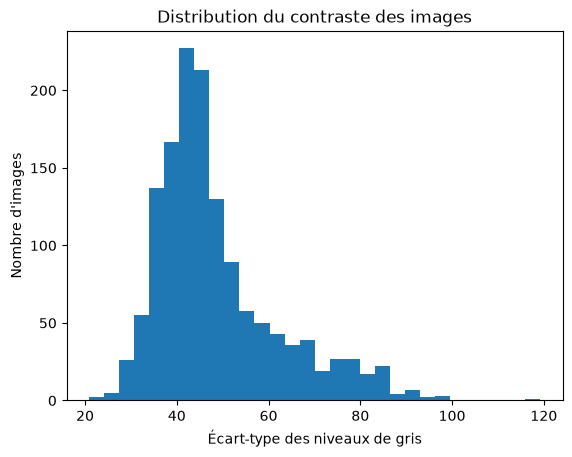

In [17]:
plt.hist(contrast_values, bins=30)

plt.xlabel("Écart-type des niveaux de gris")
plt.ylabel("Nombre d'images")
plt.title("Distribution du contraste des images")

plt.show()

- L'axe horizontal représente l'écart-type des niveaux de gris pour chaque image.
- Plus l'écart-type est faible moins l'image a de contrastes
- Plus l'écart-type est élevé plus l'mage a de contrastes
- L'axe vertical représente le nombre d'images ayant ce niveau de contraste.


La distribution semble s'étaler de 20 à 120, donc les images n'ont pas toute le même contraste.

Les images IRM présentent donc des niveaux de contraste variables. Certaines structures cérébrales sont peu différenciées, ce qui peut limiter l'extraction des caractéristiques par un modèle de deep learning.

Afin d'améliorer la répartition des intensités lumineuses, une étape d'égalisation d'histogramme des niveaux de gris devra être ajoutée au prétraitement.

L'égalisation d'histogramme est une technique de traitement d'image qui consiste à redistribuer les niveaux de gris d'une image afin d'utiliser une plus grande partie de la plage d'intensité disponible.

Cette transformation permet d'augmenter le contraste et de rendre certaines structures plus visibles.

Observons sur un exemple l'effet d'une égalisation d'histogramme des niveaux de gris:

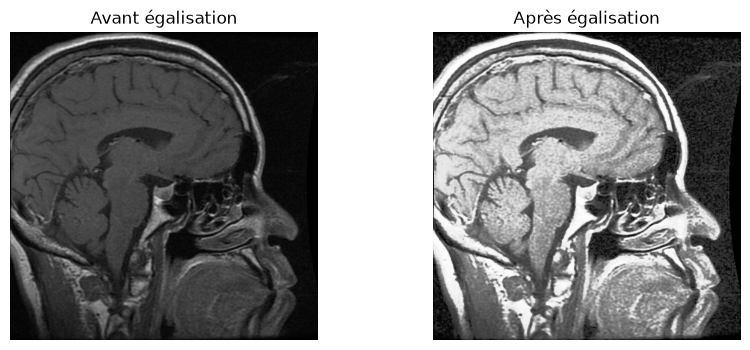

In [18]:
gray_before = image[0].numpy()

gray_after = cv2.equalizeHist(gray_before)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray_before, cmap="gray")
plt.title("Avant égalisation")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(gray_after, cmap="gray")
plt.title("Après égalisation")
plt.axis("off")

plt.show()

**À gauche : (avant égalisation)**

L'image originale est plutôt sombre et les différences entre les zones sont faibles.

Concrètement :

- beaucoup de pixels ont des niveaux de gris proches ;
- certaines zones du cerveau sont difficiles à distinguer ;
- l'image manque un peu de contraste.


**À droite : (après égalisation)**

Le programme a étalé les niveaux de gris pour mieux utiliser toute la plage disponible.

Résultat :

- les zones sombres deviennent plus sombres ;
- les zones claires deviennent plus claires ;
- les différences entre les structures du cerveau ressortent davantage.

En regardant l'image de droite, on voit mieux :

- les contours du cerveau ;
- les détails internes.

L'égalisation n'ajoute pas de détails (elle ne fait pas apparaitre une information initialement invisible), elle rend simplement les différences initialement présentes plus visibles.  

L'égalisation d'histogramme améliore le contraste de l'image. Après traitement, les différentes structures du cerveau sont plus visibles grâce à une meilleure répartition des niveaux de gris.

## 2. Prétraitement des images et extraction des caractéristiques

On récupère tous les chemins des images.

In [19]:
# Images non labellisées
unlabeled_paths = list((DATA_DIR / "sans_label").glob("*.jpg"))

# Images cancer
cancer_paths = list((DATA_DIR / "avec_labels" / "cancer").glob("*.jpg"))

# Images normales
normal_paths = list((DATA_DIR / "avec_labels" / "normal").glob("*.jpg"))

# On fusionne les données labelisées
labeled_paths = cancer_paths + normal_paths

# On créé les labels associés (On code 0 pour cancer et 1 pour normal, on multiplie par la longueur des vecteurs et on concatène le tout)
labels = ([0] * len(cancer_paths) + [1] * len(normal_paths))

print("Nombre total d'images :", len(unlabeled_paths) + len(labeled_paths))

Nombre total d'images : 1506


On sépare notre jeu de données labellisé en un jeu d'entrainement, un jeu de validation, et un jeu de test.

In [20]:
# Séparation du jeu de données en jeu d'entraînement et jeu de validation_test
train_paths, validation_test_paths, train_labels, validation_test_labels = train_test_split(labeled_paths,
                                                                                            labels,
                                                                                            test_size=0.2,   # 20 % des images seront utilisées pour le validation_test
                                                                                            stratify=labels, # Conservation de la proportion cancer / normal
                                                                                            random_state=42) # Pour obtenir toujours le même découpage
# Séparation du jeu de données validation_test en jeu de validation et jeu de test
validation_paths, test_paths, validation_labels, test_labels = train_test_split(validation_test_paths, 
                                                                                validation_test_labels,
                                                                                test_size = 0.5, # 10% des images labelliséesserviront au jeux de validation et 10% au jeu jeu de test
                                                                                stratify = validation_test_labels,
                                                                                random_state = 42)

Toutes les images sont aux mêmes dimensions 512 x 512 , et toutes en RGB, mais étant donné que nous allons utiliser ResNet50, nous devons les redimentionner en 224 x 224 pixels.

In [21]:
# Pipeline de transformation appliqué aux images avant passage dans ResNet
transform = transforms.Compose([transforms.Resize((224, 224)), # Redimensionnement de 512x512 vers 224x224 (Taille attendue par ResNet50)
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalisation avec les valeurs RGB utilisées lors de l'entraînement ImageNet

On charge le modèle ResNet50 préentrainé.

In [22]:
# Chargement de ResNet50 avec les poids appris sur ImageNet
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

Mais nous ne voulons pas classifier. Nous voulons récupérer les caractéristiques visuelles, donc on gèle les paramètres du modèle
La consigne recommande :  Geler les couches convolutionnelles.

In [23]:
# Désactivation de l'apprentissage des poids
# Le réseau sera utilisé uniquement comme extracteur de features
for param in model.parameters():
    param.requires_grad = False

On retire la couche de classification.
La dernière couche de ResNet sert à prédire 1000 classes ImageNet.
Elle ne nous intéresse pas.

In [24]:
# Suppression de la dernière couche "fully connected"
# On conserve uniquement la partie extraction de caractéristiques
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

In [25]:
# Mise du modèle en mode évaluation
# Désactive notamment certains comportements liés à l'entraînement
# Le [:-1] signifie que l'on supprimes la dernière couche (fc) de ResNet50.
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, ker


    - Conv2d : extrait des caractéristiques visuelles (contours, textures, formes...).
    - BatchNorm2d : stabilise et accélère l'apprentissage en normalisant les activations.
    - ReLU : introduit de la non-linéarité pour permettre au réseau d'apprendre des représentations complexes.
    - MaxPool2d : réduit progressivement la taille des cartes de caractéristiques tout en conservant les informations importantes.
    - Bottleneck : bloc caractéristique de ResNet qui empile plusieurs convolutions avec des connexions résiduelles (skip connections). Ces connexions facilitent l'entraînement de réseaux très profonds.
    - AdaptiveAvgPool2d(output_size=(1,1)) : agrège les informations spatiales en un vecteur compact.


ResNet50 a été entraîné sur le jeu de données ImageNet afin de reconnaître 1000 catégories d'objets. Pour cela, le modèle fonctionne en deux étapes :  

Il extrait automatiquement les caractéristiques importantes de l'image (formes, contours, textures, motifs, etc.).  
Il utilise ces caractéristiques pour prédire à quelle catégorie appartient l'image.  

Le fonctionnement complet de ResNet50 est donc le suivant :  

Image  
   │  
   ▼  
Convolutions + blocs ResNet  
   │  
   ▼  
Vecteur de 2048 caractéristiques  
   │  
   ▼  
Couche FC (classification)  
   │  
   ▼  
1000 classes ImageNet  

Dans notre projet, nous ne cherchons pas à classifier les images selon les classes d'ImageNet, mais à obtenir une représentation numérique de chaque IRM afin de réaliser du clustering et de l'apprentissage semi-supervisé.  

Nous supprimons donc la dernière couche de classification (fc) et conservons uniquement les couches d'extraction de caractéristiques. Le modèle devient alors :  

Image  
   │  
   ▼  
Convolutions + blocs ResNet  
   │  
   ▼  
AdaptiveAvgPool2d  
   │  
   ▼  
Vecteur de 2048 caractéristiques (embedding)  

Chaque image est ainsi représentée par un vecteur de 2048 valeurs, appelé embedding, qui résume son contenu visuel et servira de données d'entrée pour les étapes suivantes du projet (clustering et labellisation semi-supervisée).  
(Quelle que soit l'image en entrée, ResNet50 extrait toujours un vecteur de 2048 valeurs qui décrit son contenu visuel.)

On créé une fonction de chargement et extraction d'un embedding.

In [26]:
def extract_embedding(image_path):

    # Lecture de l'image JPEG
    image = read_image(str(image_path))


    # Conversion en niveaux de gris
    # Les images étant principalement grayscale stockées en RGB,
    # on utilise le premier canal pour récupérer l'intensité lumineuse
    gray = image[0].numpy()


    # Egalisation de l'histogramme des niveaux de gris
    gray = cv2.equalizeHist(gray)


    # Reconstruction en 3 canaux
    # ResNet50 attend une image RGB (3, H, W)
    image = np.stack([gray, gray, gray], axis=0)


    # Conversion en Tensor PyTorch et normalisation entre 0 et 1
    image = torch.tensor(image).float() / 255.0


    # Prétraitement attendu par ResNet50
    image = transform(image)


    # Ajout de la dimension batch
    # Passage de (3,224,224) à (1,3,224,224)
    image = image.unsqueeze(0)


    # Extraction des caractéristiques
    with torch.no_grad():

        embedding = feature_extractor(image)


    # Passage de (1,2048,1,1) à (2048)
    embedding = embedding.squeeze()


    # Conversion en tableau numpy
    return embedding.numpy()

Avant de lancer toutes les images, on teste sur une image.

In [27]:
# Extraction du vecteur pour la première image
test_embedding = extract_embedding(train_paths[0])


# Vérification de la taille du vecteur
print(test_embedding.shape)

(2048,)


Le modèle a extrait bien un vecteur caractéristique constitué de 2048 caractéristiques décrivant cette image.

Extraction des embeddings pour toutes les images.

In [28]:
# Liste qui contiendra tous les vecteurs pour les images du jeu d'entrainement
train_embeddings = []

# Parcours de toutes les images du jeu d'entrainement
for image_path in tqdm(train_paths):

    # Extraction du vecteur de caractéristiques
    embedding = extract_embedding(image_path)

    # Ajout à la liste
    train_embeddings.append(embedding)

# Transformation de la liste en matrice NumPy
train_embeddings = np.array(train_embeddings)

# Vérification de la dimension
print(train_embeddings.shape)

100%|█████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 17.20it/s]

(80, 2048)


In [29]:
# Liste qui contiendra tous les vecteurs pour les images du jeu de validation
validation_embeddings = []

# Parcours de toutes les images du jeu de validation
for image_path in tqdm(validation_paths):

    # Extraction du vecteur de caractéristiques
    embedding = extract_embedding(image_path)

    # Ajout à la liste
    validation_embeddings.append(embedding)

# Transformation de la liste en matrice NumPy
validation_embeddings = np.array(validation_embeddings)

# Vérification de la dimension
print(validation_embeddings.shape)

100%|█████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 17.24it/s]

(10, 2048)


In [30]:
# Liste qui contiendra tous les vecteurs pour les images du jeu de test
test_embeddings = []

# Parcours de toutes les images du jeu de test
for image_path in tqdm(test_paths):

    # Extraction du vecteur de caractéristiques
    embedding = extract_embedding(image_path)

    # Ajout à la liste
    test_embeddings.append(embedding)

# Transformation de la liste en matrice NumPy
test_embeddings = np.array(test_embeddings)

# Vérification de la dimension
print(test_embeddings.shape)

100%|█████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 15.33it/s]

(10, 2048)


On fait la même chose pour les images non labellisées

In [31]:
# Liste qui contiendra tous les vecteurs pour les images non labellisées
unlabeled_embeddings = []

# Parcours de toutes les images non labellisées
for image_path in tqdm(unlabeled_paths):

    # Extraction du vecteur de caractéristiques
    embedding = extract_embedding(image_path)

    # Ajout à la liste
    unlabeled_embeddings.append(embedding)

# Transformation de la liste en matrice NumPy
unlabeled_embeddings = np.array(unlabeled_embeddings)

# Vérification de la dimension
print(unlabeled_embeddings.shape)

100%|█████████████████████████████████████████████████████| 1406/1406 [01:18<00:00, 17.81it/s]

(1406, 2048)


Création des DataFrame pandas.

In [32]:
# Conversion du jeu d'entrainement en DataFrame pour faciliter l'analyse
features_train_df = pd.DataFrame(train_embeddings)

# Affichage des premières lignes
features_train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.000000,0.000000,0.528756,0.016513,0.070781,0.0,0.067540,0.061959,0.534554,0.0,...,0.0,0.012734,0.052251,0.049266,0.244174,0.094647,1.295383,0.062644,0.0,0.054353
1,0.000000,0.038253,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.006556,0.110092,0.554611,0.000000,0.0,0.007482
2,0.000000,0.000000,0.017940,0.000000,0.032326,0.0,0.022537,0.000000,0.649337,0.0,...,0.0,0.000000,0.023177,0.000000,0.032605,0.000000,0.260303,0.000000,0.0,0.002190
3,0.000000,0.000000,0.101364,0.000000,0.048276,0.0,0.000000,0.000000,0.039735,0.0,...,0.0,0.000000,0.003148,0.000000,0.097520,0.000000,1.189408,0.000000,0.0,0.043557
4,0.202359,0.000000,0.017486,0.000000,0.089004,0.0,0.000000,0.000000,0.191967,0.0,...,0.0,0.034245,0.000000,0.000000,0.204104,0.015010,0.054009,0.029835,0.0,0.000000


In [33]:
# Conversion du jeu de validation en DataFrame pour faciliter l'analyse
features_validation_df = pd.DataFrame(validation_embeddings)

# Affichage des premières lignes
features_validation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.000000,0.000000,0.013985,0.0,0.188519,0.000000,0.036756,0.000000,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.018669,0.000000,0.000000,0.000000,0.0,0.000000
1,0.000000,0.134971,0.119657,0.0,0.000000,0.000000,0.020527,0.000000,0.032215,0.0,...,0.000000,0.0,0.000000,0.000000,0.010511,0.000000,0.465431,0.000000,0.0,0.068570
2,0.000000,0.000014,0.000000,0.0,0.046563,0.000000,0.852546,0.000000,0.213154,0.0,...,0.000000,0.0,0.075882,0.000000,0.081446,0.100767,0.270754,0.000000,0.0,0.038718
3,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.013055,0.0,...,0.021006,0.0,0.000000,0.000000,0.002786,0.000000,1.043967,0.000000,0.0,0.000000
4,0.023633,0.001546,0.300363,0.0,0.134607,0.004086,0.166973,0.017346,0.079975,0.0,...,0.000000,0.0,0.035363,0.230198,0.000000,0.064190,0.654749,0.002037,0.0,0.023717


In [34]:
# Conversion du jeu de test en DataFrame pour faciliter l'analyse
features_test_df = pd.DataFrame(test_embeddings)

# Affichage des premières lignes
features_test_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.000000,0.000000,0.842783,0.092487,0.209222,0.000000,0.153163,0.037190,0.202399,0.000000,...,0.000000,0.039154,0.028540,0.00929,0.043176,0.219892,1.059712,0.158503,0.0,0.111267
1,0.000000,0.010518,0.440102,0.000000,0.092997,0.005608,0.012839,0.035254,0.000000,0.004844,...,0.003589,0.002437,0.016565,0.00000,0.031953,0.000000,0.756717,0.021302,0.0,0.093632
2,0.014147,0.000000,0.078081,0.000000,0.199621,0.000000,0.000540,0.000000,0.000000,0.000000,...,0.000000,0.009828,0.000000,0.00000,0.019659,0.056737,0.588497,0.000000,0.0,0.000000
3,0.000000,0.027946,1.128063,0.169519,0.036945,0.000000,0.000000,0.092957,0.156768,0.000000,...,0.000000,0.123725,0.006823,0.00000,0.001717,0.076162,0.635324,0.147326,0.0,0.028731
4,0.084034,0.094251,0.017538,0.000000,0.030840,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.034063,0.00000,0.051159,0.165282,0.209144,0.000000,0.0,0.002900


In [35]:
# Conversion du jeu d'entrainement en DataFrame pour faciliter l'analyse
features_unlabeled_df = pd.DataFrame(unlabeled_embeddings)

# Affichage des premières lignes
features_unlabeled_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.000000,0.000000,0.637243,0.0,0.019871,0.008631,0.124625,0.006778,1.438050,0.000000,...,0.016119,0.023981,0.005802,0.503050,0.000000,0.258634,1.489994,0.054547,0.000000,0.000000
1,0.000000,0.031803,0.628551,0.0,0.000000,0.000000,0.220223,0.000725,0.629656,0.000000,...,0.011574,0.000000,0.187238,0.006735,0.115626,0.119790,0.416535,0.000000,0.000000,0.055592
2,0.163314,0.014064,0.015661,0.0,0.006447,0.000056,1.968672,0.006613,0.000000,0.034801,...,0.181493,0.000000,0.428647,0.082045,0.050405,0.089806,1.403532,0.012699,0.077939,0.010228
3,0.000000,0.015317,0.099202,0.0,0.059126,0.026371,0.039681,0.026675,0.043952,0.000000,...,0.010891,0.000000,0.024723,0.002115,0.541366,0.128863,0.415181,0.000000,0.000000,0.419827
4,0.020066,0.000000,0.177677,0.0,0.000000,0.000000,0.491518,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.251953,0.000000,0.015656,0.000000,0.289308,0.000000,0.000000,0.039858


In [36]:
features_train_df.shape

(80, 2048)

In [37]:
features_validation_df.shape

(10, 2048)

In [38]:
features_test_df.shape

(10, 2048)

In [39]:
features_unlabeled_df.shape

(1406, 2048)

Sauvegarde des embeddings

In [40]:
# Sauvegarde des caractéristiques dans des fichier CSV
features_train_df.to_csv("resnet50_embeddings_train.csv",index=False)
features_validation_df.to_csv("resnet50_embeddings_validation.csv",index=False)
features_test_df.to_csv("resnet50_embeddings_test.csv",index=False)
features_unlabeled_df.to_csv("resnet50_embeddings_unlabeled.csv",index=False)

On sauvegarde aussi les chemins des images.

In [41]:
# Création de DataFrame contenant les chemins
train_paths_df = pd.DataFrame({"image_path": [str(p) for p in train_paths],"label": train_labels})
validation_paths_df = pd.DataFrame({"image_path": [str(p) for p in validation_paths],"label": validation_labels})
test_paths_df = pd.DataFrame({"image_path": [str(p) for p in test_paths],"label": test_labels})
unlabeled_paths_df = pd.DataFrame({"image_path": [str(p) for p in unlabeled_paths]})

# Sauvegarde
train_paths_df.to_csv("train_paths.csv", index=False)
validation_paths_df.to_csv("validation_paths.csv", index=False)
test_paths_df.to_csv("test_paths.csv", index=False)
unlabeled_paths_df.to_csv("unlabeled_paths.csv", index=False)

## 3. Réduction de dimension et clustering des embeddings

On commence par standardiser les embbeddings. (Les embeddings ResNet50 sont 2048 valeurs numériques.Certaines dimensions peuvent avoir des amplitudes différentes. K-Means utilise la distance entre les points. Donc une feature avec de grandes valeurs pourrait prendre trop d'importance. On transforme les données pour obtenir :  
moyenne = 0  
écart-type = 1

In [42]:
# Création du standardiseur
scaler = StandardScaler()

# Apprentissage du scaler uniquement sur les images sans labels
# Important : on ne mélange pas les images annotées et non annotées
features_unlabeled_scaled = scaler.fit_transform(unlabeled_embeddings)

# Vérification de la nouvelle dimension

print(features_unlabeled_scaled.shape)

(1406, 2048)


On effectue une réduction dimentionnelle avec PCA.  
1 image a 2048 caractéristiques c'est donc mmpossible à représenter graphiquement.  
PCA permet de créer de nouvelles dimensions qui résument l'information principale.  
On passe donc de 2048 dimensions à seulement 2 dimensions.

In [43]:
# Création du modèle PCA
pca = PCA(n_components=2)

# Transformation des embeddings
features_unlabeled_pca = pca.fit_transform(features_unlabeled_scaled)

# Vérification
print(features_unlabeled_pca.shape)

(1406, 2)


Regardons si les données sont naturellement séparées

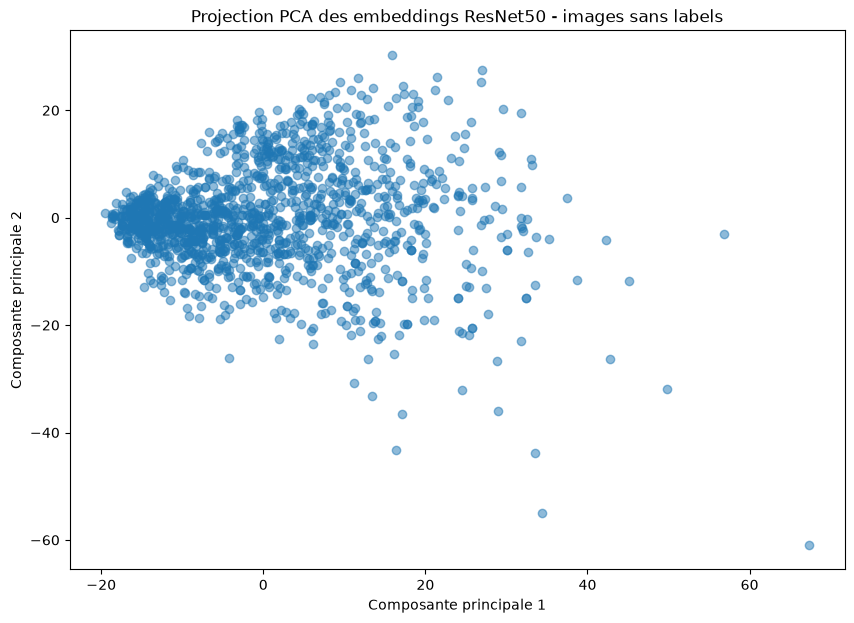

In [44]:
# Taille du graphique
plt.figure(figsize=(10,7))

# Affichage des images dans l'espace PCA
plt.scatter(features_unlabeled_pca[:,0],features_unlabeled_pca[:,1],alpha=0.5)

plt.xlabel("Composante principale 1")

plt.ylabel("Composante principale 2")

plt.title("Projection PCA des embeddings ResNet50 - images sans labels")

plt.show()

La projection PCA permet de visualiser la distribution des embeddings. Les groupes ne sont pas séparés, ce qui est attendu puisque les images n'ont pas encore été regroupées par un algorithme de clustering.

Utilisons un algorithme de clustering avec K-Means.  
On a deux clusters (cancer et normal).

In [45]:
# Création du modèle K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Apprentissage et attribution des clusters
clusters_kmeans = kmeans.fit_predict(features_unlabeled_scaled)

# Nombre d'images dans chaque cluster
print(np.unique(clusters_kmeans,return_counts=True))

(array([0, 1], dtype=int32), array([833, 573]))


Visualisons des clusters en colorant les points selon leur cluster.

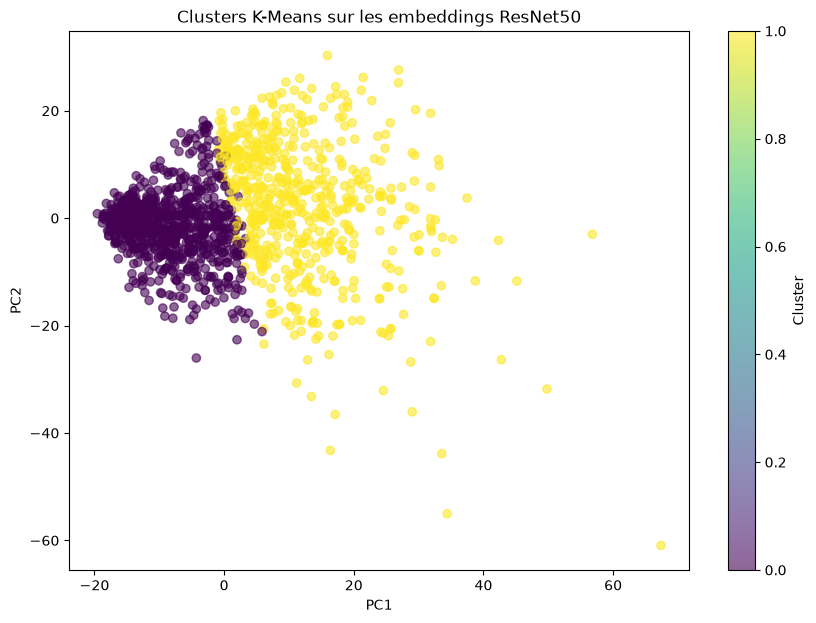

In [46]:
plt.figure(figsize=(10,7))

plt.scatter(features_unlabeled_pca[:,0],features_unlabeled_pca[:,1],c=clusters_kmeans,cmap="viridis",alpha=0.6)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Clusters K-Means sur les embeddings ResNet50")

plt.colorbar(label="Cluster")

plt.show()

K-means semble distinguer deux groupes différents.

On créé de pseudos labels. Les clusters deviennent nos labels faibles, donc nn crée un nouveau DataFrame séparé contenant ces derniers
(on ne touche pas aux labels experts).

In [47]:
# Création du dataset faiblement labellisé
pseudo_labels_df = pd.DataFrame({"image_path": [str(p) for p in unlabeled_paths],"pseudo_label": clusters_kmeans})

# Vérification
pseudo_labels_df.head()

,image_path,pseudo_label
0,mri_dataset_brain_cancer_oc/sans_label/9b2f0d9...,1
1,mri_dataset_brain_cancer_oc/sans_label/1528e16...,0
2,mri_dataset_brain_cancer_oc/sans_label/f4067a4...,0
3,mri_dataset_brain_cancer_oc/sans_label/2a87b19...,1
4,mri_dataset_brain_cancer_oc/sans_label/b5e72ee...,0


On va maintenant mesurer si les clusters ressemblent aux vrais labels. On transforme les images annotées avec le même scaler.

In [48]:
# Standardisation
features_labeled_train_scaled = scaler.transform(train_embeddings)

In [49]:
# prediction des cluster
clusters_labeled_train = kmeans.predict(features_labeled_train_scaled)

In [50]:
# calcul ARI
ari_score = adjusted_rand_score(train_labels,clusters_labeled_train)

print("Score ARI :",ari_score)

Score ARI : 0.15056481807417837


Score ARI > 0, donc le modèle ne regroupe pas les images totalement au hasard.  
clustering K-Means trouve une structure dans les embeddings, mais cette structure ne correspond que partiellement aux vrais labels des radiologues.

On va comparer ces performances avec un autre algorithme d clustering DBSCAN.

Contrairement à K-Means, on ne donne pas directement le nombre de groupes à DBSCAN, il cherche lui-même :
des zones où les images sont proches, des points isolés (bruit).

Les deux paramètres principaux :  
- eps (distance maximale entre deux points pour être considérés voisins).  
- min_samples (nombre minimum de voisins nécessaires pour créer un groupe).


Pour utiliser DBSCAN, on doit au préalable fixer le paramètre eps.  
Il représente la distance maximale entre deux points pour qu'ils soient considérés comme voisins.  
Pour ce faire nous allons tracer la courbe des distances des 10 plus proches voisins. (On considère qu'un point appartient à une région dense s'il possède au moins 10 voisins dans son voisinage eps. Donc on fixera le second paramètre min_samples = 10)

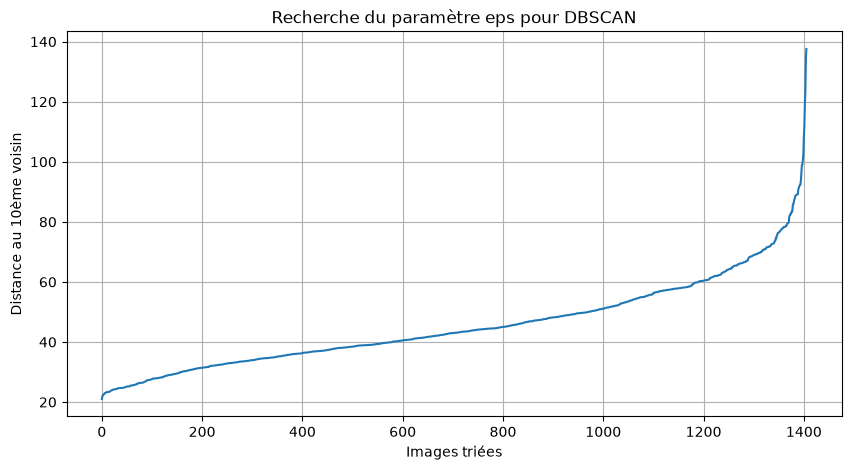

In [51]:
k = 10

# Calcul des k plus proches voisins
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(features_unlabeled_scaled)

# Distances et indices des voisins
distances, indices = neighbors.kneighbors(features_unlabeled_scaled)

distances_10 = distances[:, k-1]

# Tri des distances
distances_sorted = np.sort(distances_10)


# Affichage

plt.figure(figsize=(10,5))

plt.plot(distances_sorted)

plt.xlabel("Images triées")

plt.ylabel("Distance au 10ème voisin")


plt.title("Recherche du paramètre eps pour DBSCAN")


plt.grid()

plt.show()

Par lecture graphique on a que l'eps optimal se situerait aux allentours de 70.

In [52]:
# Création du modèle DBSCAN
dbscan = DBSCAN(eps=70,min_samples=10)

# Application du clustering sur les embeddings standardisés
clusters_dbscan = dbscan.fit_predict(features_unlabeled_scaled)

# Affichage des clusters trouvés
print(np.unique(clusters_dbscan,return_counts=True))

(array([-1,  0]), array([  66, 1340]))


Visualisation des clusters DBSCAN

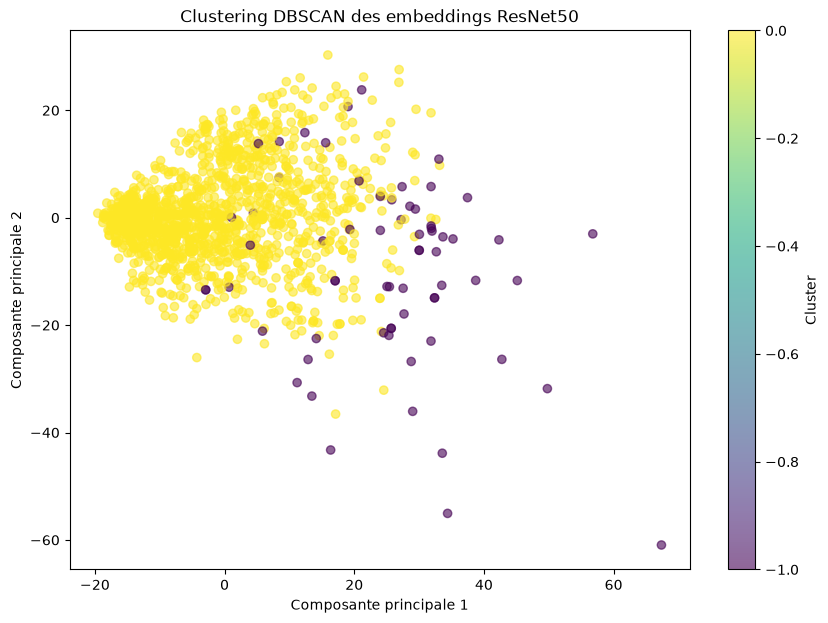

In [53]:
# Création du graphique
plt.figure(figsize=(10,7))


# Affichage des images dans l'espace PCA
# La couleur correspond au cluster DBSCAN
plt.scatter(features_unlabeled_pca[:,0],features_unlabeled_pca[:,1],c=clusters_dbscan,cmap="viridis",alpha=0.6)

# Nom des axes
plt.xlabel("Composante principale 1")

plt.ylabel("Composante principale 2")

# Titre
plt.title("Clustering DBSCAN des embeddings ResNet50")

# Affichage de la légende des couleurs
plt.colorbar(label="Cluster")

plt.show()

DBSCAN ne semble distionguer qu'un seul groupe, et quelques points isolés.

Comptons le nombre de cluster obtenu.

In [54]:
# Nombre de clusters trouvés par DBSCAN
# On retire -1 car il correspond au bruit
nombre_clusters = len(set(clusters_dbscan)-{-1})

print("Nombre de clusters trouvés :", nombre_clusters)

Nombre de clusters trouvés : 1


DBSCAN ne trouve qu'un groupe, ce qui confirme notre observation précédente.

Création des pseudo-labels DBSCAN.  
Comme pour K-Means, on crée un DataFrame séparé.

In [55]:
# Création du DataFrame contenant les pseudo-labels DBSCAN
pseudo_labels_dbscan_df = pd.DataFrame({"image_path": [str(p) for p in unlabeled_paths],"pseudo_label_dbscan": clusters_dbscan})

# Affichage des premières lignes
pseudo_labels_dbscan_df.head()

,image_path,pseudo_label_dbscan
0,mri_dataset_brain_cancer_oc/sans_label/9b2f0d9...,0
1,mri_dataset_brain_cancer_oc/sans_label/1528e16...,0
2,mri_dataset_brain_cancer_oc/sans_label/f4067a4...,0
3,mri_dataset_brain_cancer_oc/sans_label/2a87b19...,0
4,mri_dataset_brain_cancer_oc/sans_label/b5e72ee...,0


DBSCAN n'a pas de méthode : "dbscan.predict()"  
contrairement à K-Means.On doit donc appliquer DBSCAN directement aux images labellisées.

In [56]:
# Création d'un nouveau modèle DBSCAN
dbscan_labeled = DBSCAN(eps=70, min_samples=10)

# Application sur les embeddings des images annotées
clusters_train_dbscan = dbscan_labeled.fit_predict(features_labeled_train_scaled)

# Affichage des groupes trouvés
print(np.unique(clusters_train_dbscan,return_counts=True))

(array([-1,  0]), array([ 3, 77]))


DBSCAN ne distingue qu'une seule classe, et des points isolés.

Calcul du score ARI DBSCAN

In [57]:
# Calcul du score ARI
ari_dbscan = adjusted_rand_score(train_labels,clusters_train_dbscan)

# Affichage
print("Score ARI DBSCAN :",ari_dbscan)

Score ARI DBSCAN : -0.001204733333861725


DBSCAN fait pire que le hasard pour séparer les classes.

Comparaison K-Means / DBSCAN

In [58]:
# Création d'un tableau comparatif
comparison_df = pd.DataFrame({"Méthode": ["K-Means", "DBSCAN"], "ARI": [ari_score,ari_dbscan]})

comparison_df

,Méthode,ARI
0,K-Means,0.150565
1,DBSCAN,-0.001205


Etant donné les performace ARI des deux modèles de clustering, on utilisera K-Means lors de l'apprentissage semi supervisé.

## 4. Entraînement d'un CNN : approche supervisée vs semi-supervisée

Nous allons commencer par l'approche supervisée, puis nous ferons l'approche semi-supervisée.

Voici notre démarche :  
- Préparer le dataset annoté
- Faire le train/test split
- Créer le Dataset PyTorch
- Créer les DataLoader
- Charger ResNet50
- Entraîner le modèle
- Évaluer le modèle

Pour comparer nos modèles on utilisera la métrique F1-score, qui offre un bon compromis entre le rappel et la précision.

In [59]:
# ============================================================
# FIXATION DES GRAINES ALÉATOIRES
# Permet de rendre les résultats reproductibles
# ============================================================

SEED = 42              # Graine aléatoire utilisée pour assurer la reproductibilité

np.random.seed(SEED)   # Fixe la graine aléatoire de NumPy
torch.manual_seed(SEED) # Fixe la graine aléatoire de PyTorch

### Préparation du dataset annoté

À ce stade, on dispose des dataframe features_df et paths_df.  
Pour entraîner un CNN, on n'utilise plus les embeddings.  
  
Le CNN doit relire les images originales.

On crée donc un DataFrame contenant le chemin de chaque image annotée ainsi que leur label.

In [60]:
print("Train :", np.unique(train_labels, return_counts=True))
print("Validation :", np.unique(validation_labels, return_counts=True))
print("Test :", np.unique(test_labels, return_counts=True))

Train : (array([0, 1]), array([40, 40]))
Validation : (array([0, 1]), array([5, 5]))
Test : (array([0, 1]), array([5, 5]))


### Création du Dataset PyTorch

on crée notre classe personnalisée.

In [61]:
# Création d'une classe Dataset compatible avec PyTorch
class BrainMRIDataset(Dataset):

    # Initialisation du Dataset
    def __init__(self, image_paths, labels, transform=None):

        # Sauvegarde des chemins des images
        self.image_paths = image_paths

        # Sauvegarde des labels
        self.labels = labels

        # Sauvegarde des transformations
        self.transform = transform


    # Retourne le nombre total d'images
    def __len__(self):

        return len(self.image_paths)


    # Retourne une image et son label
    def __getitem__(self, idx):

        # Récupération du chemin de l'image
        image_path = self.image_paths[idx]

        # Récupération du label
        label = self.labels[idx]

        # Ouverture de l'image
        image = Image.open(image_path).convert("RGB")

        # Application des transformations
        if self.transform:
            image = self.transform(image)

        # Retour de l'image et du label
        return image, label

On crée maintenant les transformations.

In [62]:
# Prétraitement des images avant leur passage dans ResNet50
transform = transforms.Compose([transforms.Resize((224, 224)), # Redimensionnement des images
                                transforms.ToTensor(), # Conversion de l'image PIL en Tensor
                                transforms.Normalize( mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalisation avec les statistiques d'ImageNet

In [63]:
# Jeu d'entraînement
train_dataset = BrainMRIDataset(train_paths,train_labels,transform=transform)

# Jeu de validation
validation_dataset = BrainMRIDataset(validation_paths,validation_labels,transform=transform)

# Jeu de test
test_dataset = BrainMRIDataset(test_paths, test_labels, transform=transform)

on vérifie que tout fonctionne.

In [64]:
# Lecture de la première image
image, label = train_dataset[0]

print("Dimensions :", image.shape)
print("Label :", label)

Dimensions : torch.Size([3, 224, 224])
Label : 0


### création des DataLoader

BrainMRIDataset sait charger une seule image à la fois.  
Par exemple : image, label = train_dataset[0]
  
Mais un CNN n'entraîne généralement pas une image après l'autre. Il travaille sur des mini-lots (batches). Le DataLoader s'occupe automatiquement de créer ces lots.

In [65]:
# Création du DataLoader pour le jeu d'entraînement
train_loader = DataLoader(train_dataset,  # Dataset utilisé
                          batch_size=16,  # Nombre d'images traitées en une fois (on a 80 images donc 16 nous permet d'avoir 5 batchs)
                          shuffle=True)   # Mélange des images à chaque époque pour éviter que le modèle n'apprenne un ordre

# Création du DataLoader pour le jeu de validation
validation_loader = DataLoader(validation_dataset, # Dataset utilisé 
                               batch_size=16,      # Nombre d'images traitées en une fois (on a 80 images donc 16 nous permet d'avoir 5 batchs)
                               shuffle=False)      # Pas de mélange pendant l'évaluation

# Création du DataLoader pour le jeu de test
test_loader = DataLoader(test_dataset,   # Dataset utilisé
                         batch_size=16,  # Nombre d'images traitées en une fois (on a 80 images donc 16 nous permet d'avoir 5 batchs)
                         shuffle=False)  # Pas de mélange pendant l'évaluation

On vérifie que tout fonctionne.

In [66]:
# Lecture du premier batch
images, labels = next(iter(train_loader))

print("Dimensions des images :", images.shape)
print("Dimensions des labels :", labels.shape)

Dimensions des images : torch.Size([16, 3, 224, 224])
Dimensions des labels : torch.Size([16])


Ce qui signifie :  
- 16 images
- 3 canaux RGB
- 224 × 224 pixels
- 16 labels correspondants

### Préparation de ResNet50 pour la classification

Jusqu'à présent, nous avons utilisé ResNet50 uniquement pour extraire des embeddings.  
Cette fois, nous allons utiliser ResNet50 comme classifieur.

L'idée est la suivante :  

Image  
   │  
   ▼  
ResNet50  
   │  
   ▼  
2 neurones  
(cancer / normal)  

On charge le modèle préentrainé.

In [67]:
# Chargement de ResNet50 pré-entraîné sur ImageNet
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

On ne voulons pas réentraîner les millions de paramètres appris sur ImageNet. Donc on les fige.

ResNet50 sait déjà reconnaître énormément de motifs visuels :  
- contours 
- textures 
- formes 
- contrastes

Nous souhaitons conserver ces connaissances, et allons uniquement apprendre à distinguer :
- cancer
- normal

In [68]:
# Désactivation de l'apprentissage des couches convolutionnelles
for param in model.parameters():
    param.requires_grad = False

On remplace la dernière couche.

La dernière couche actuelle ressemble à :

2048  
 │  
 ▼  
1000 classes  

Or, on veut:

2048  
 │  
 ▼  
2 classes  

In [69]:
# Nombre d'entrées de la dernière couche
num_features = model.fc.in_features

# Remplacement de la couche finale
model.fc = torch.nn.Linear(num_features,2)

On effectue une vérification sur la dernière couche.

In [70]:
print(model.fc)

Linear(in_features=2048, out_features=2, bias=True)


On vérifie les paramètres entraînables. Comme nous avons gelé tout le réseau, seuls les paramètres de model.fc doivent être entraînés.

In [71]:
# Comptage des paramètres entraînables
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)


print("Nombre de paramètres entraînables :", trainable_params)

Nombre de paramètres entraînables : 4098


4098 = 2048 × 2 + 2 biais

Le jeu annoté ne contient que 100 images. Si on entraînait tous les paramètres de ResNet50, le modèle risquerait fortement le surapprentissage (overfitting).
En gelant les couches convolutionnelles et en n'entraînant que la dernière couche, on profite des connaissances acquises sur ImageNet tout en adaptant le modèle à notre problème de classification binaire. C'est le principe du transfer learning, qui est particulièrement adapté lorsque le jeu de données est de petite taille.

### Entrainer le modèle

Dans un premier temps on va définir la fonction de perte.  

Comme nous avons 2 classes (cancer et normal), nous utilisons CrossEntropyLoss. Cette fonction est utilisée pour les problèmes de classification multiclasse (y compris binaire avec deux sorties).  

À chaque image, le modèle va produire deux scores, un pour la classe cancer et un second pour la classe normal. CrossEntropyLoss compare ces scores au vrai label et calcule l'erreur.

In [72]:
# Fonction de perte utilisée pour mesurer l'erreur du modèle
criterion = torch.nn.CrossEntropyLoss()

Comme seules les dernières couches sont entraînées, on demande à l'optimiseur de ne modifier que les paramètres dont requires_grad=True.  
Adam est un optimiseur qui adapte automatiquement la taille des mises à jour des poids.

In [73]:
# Optimiseur chargé de mettre à jour les poids du modèle
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), # Seuls les paramètres entraînables sont optimisés
                             lr=0.001) # Taux d'apprentissage

Nous allons entraîner le modèle pendant 10 époques.  
Une époque signifie que le modèle voit une fois toutes les images du jeu d'entraînement.

In [74]:
# Nombre d'époques
num_epochs = 10


# Passage du modèle en mode entraînement
model.train()


# Boucle principale
for epoch in range(num_epochs):

    # Somme des pertes de l'époque
    running_loss = 0.0


    # Parcours des batches
    for images, labels in train_loader:

        # Remise à zéro des gradients
        optimizer.zero_grad()


        # Prédictions du modèle
        outputs = model(images)


        # Calcul de la perte
        loss = criterion(outputs, labels)


        # Calcul des gradients
        loss.backward()


        # Mise à jour des poids
        optimizer.step()


        # Accumulation de la perte
        running_loss += loss.item()


    # Affichage de la perte moyenne
    print(f"Époque {epoch+1}/{num_epochs} - "f"Loss : {running_loss/len(train_loader):.4f}")

Époque 1/10 - Loss : 0.6536
Époque 2/10 - Loss : 0.5138
Époque 3/10 - Loss : 0.4201
Époque 4/10 - Loss : 0.3589
Époque 5/10 - Loss : 0.3032
Époque 6/10 - Loss : 0.2834
Époque 7/10 - Loss : 0.2786
Époque 8/10 - Loss : 0.1970
Époque 9/10 - Loss : 0.1950
Époque 10/10 - Loss : 0.1762


Voici ce qui se passe à chaque batch:  

Pour chaque lot de 16 images :

16 images  
      │  
      ▼  
ResNet50  
      │  
      ▼  
Prédictions  
      │  
      ▼  
Calcul de la perte  
      │  
      ▼  
Calcul des gradients  
      │  
      ▼  
Mise à jour des poids  

Puis on recommence avec le batch suivant.  

Au fil des époques, la loss diminue progressivement.

### Evaluer le modèle

Nous allons calculer : Accuracy, Precision, Recall, F1-score.

In [75]:
# Passage du modèle en mode évaluation (le but ici n'est pas que le model aprenne mais qu'il évalue ses performances)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

On effectue les prédictions sur le jeu de validation, et sur le jeux d'entrainement pour vérifier qu'il n'y a pas de surapprentissage.

In [76]:
# Listes qui contiendront les vrais labels et les prédictions - VALIDATION

y_true = []
y_pred = []


# Désactivation du calcul des gradients

with torch.no_grad():

    # Parcours du jeu de validation

    for images, labels in validation_loader:

        # Prédictions du modèle

        outputs = model(images)

        # Classe prédite (0 ou 1)

        predictions = torch.argmax(outputs, dim=1)

        # Sauvegarde des vrais labels

        y_true.extend(labels.numpy())

        # Sauvegarde des prédictions

        y_pred.extend(predictions.numpy())




# =====================================================
# Evaluation sur le TRAIN
# =====================================================


# Listes qui contiendront les vrais labels et les prédictions - TRAIN

y_true_train = []
y_pred_train = []


# Désactivation du calcul des gradients

with torch.no_grad():

    # Parcours du jeu d'entraînement

    for images, labels in train_loader:

        # Prédictions du modèle

        outputs = model(images)

        # Classe prédite (0 ou 1)

        predictions = torch.argmax(outputs, dim=1)

        # Sauvegarde des vrais labels

        y_true_train.extend(labels.numpy())

        # Sauvegarde des prédictions

        y_pred_train.extend(predictions.numpy())

On calcule les métriques.

In [77]:
# =====================================================
# Calcul des métriques VALIDATION
# =====================================================

# Calcul de l'accuracy

accuracy = accuracy_score(y_true,y_pred)


# Calcul de la précision

precision = precision_score(y_true,y_pred, pos_label=0)


# Calcul du rappel

recall = recall_score(
    y_true,
    y_pred, pos_label=0
)


# Calcul du F1-score

f1 = f1_score(
    y_true,
    y_pred, pos_label=0
)



# =====================================================
# Calcul des métriques TRAIN
# =====================================================

# Calcul de l'accuracy

accuracy_train = accuracy_score(
    y_true_train,
    y_pred_train
)


# Calcul de la précision

precision_train = precision_score(
    y_true_train,
    y_pred_train, pos_label=0
)


# Calcul du rappel

recall_train = recall_score(
    y_true_train,
    y_pred_train, pos_label=0
)


# Calcul du F1-score

f1_train = f1_score(
    y_true_train,
    y_pred_train, pos_label=0
)



# =====================================================
# Affichage des résultats
# =====================================================

print("===== TRAIN =====")

print(f"Accuracy  : {accuracy_train:.3f}")

print(f"Precision : {precision_train:.3f}")

print(f"Recall    : {recall_train:.3f}")

print(f"F1-score  : {f1_train:.3f}")



print("\n===== VALIDATION =====")

print(f"Accuracy  : {accuracy:.3f}")

print(f"Precision : {precision:.3f}")

print(f"Recall    : {recall:.3f}")

print(f"F1-score  : {f1:.3f}")

===== TRAIN =====
Accuracy  : 0.950
Precision : 0.929
Recall    : 0.975
F1-score  : 0.951

===== VALIDATION =====
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1-score  : 1.000


- Accuracy : proportion de bonnes prédictions.
- Precision : parmi les images prédites "cancer", combien sont réellement des cancers .
- Recall : parmi les vrais cancers, combien ont été détectés.
- F1-score : compromis entre précision et rappel.

Le modèle ne semble pas surapprendre.

On affiche les performances du modèle.

In [78]:
# Rapport détaillé des performances sur le jeu de validation
print(classification_report(y_true,y_pred,target_names=["Cancer", "Normal"]))

              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00         5
      Normal       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Le modèle obtient une accuracy globale de 100 %, ce qui signifie qu'il classe correctement 10 images sur 10 du jeu de validation.

En détaillant les résultats par classe :  

**Cancer:**
- Précision : 1,00 → parmi toutes les images prédites comme « Cancer », toutes sont réellement des cancers.
- Rappel : 1,00 → le modèle détecte tous les cancers présents dans le jeu de test. Il n'y a donc aucun faux négatif pour cette classe.
- F1-score : 1,00 → excellent compromis entre précision et rappel.

**Normal:**
- Précision : 1,00 → toutes les images prédites comme « Normal » sont effectivement normales.
- Rappel : 1,00 → le modèle détecte toutes les images normales présentes dans le jeu de test. Il n'y a donc aucun faux négatif pour cette classe.
- F1-score : 1,00 → les performances sont très élevées.

Ces données sont à prendre avec un certain recul étant donné la faible dimension du dataset de validation.

On affiche la matrice de confusion.

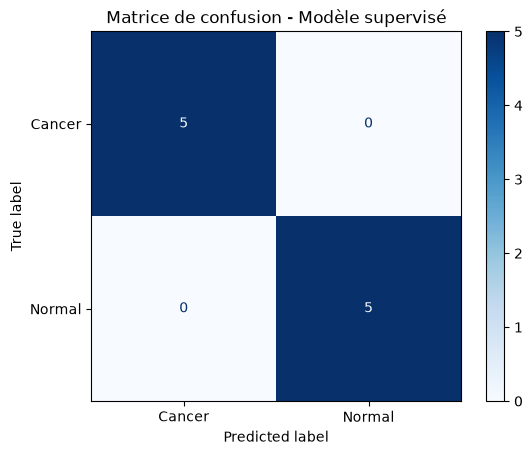

In [79]:
# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cancer", "Normal"])

disp.plot(cmap="Blues")

plt.title("Matrice de confusion - Modèle supervisé")

plt.show()

Le modèle détecte bien les 5 cancers, et 5 images sont bien détecté comme normales. Aucun faux négatif, et aucun faux positif.  

Ces données sont à prendre avec un certain recul étant donné la faible dimension du dataset de validation.

On passe à l'approche semi suppervisée:  
- Création du dataset semi-supervisé;
- créer un Dataset PyTorch avec ces 1406 images ;
- créer un DataLoader ;
- réinitialiser un nouveau ResNet50 ;
- le pré-entraîner sur les pseudo-labels ;
- reprendre ce même modèle et continuer son entraînement sur les 80 vraies images annotées ;
- enfin comparer les performances avec le modèle supervisé.

### Création du dataset semi-supervisé

Nous devons maintenant associer les 1406 chemins d'images sans labels ; les clusters K-Means obtenus dans la partie 3.

Ces clusters deviennent nos pseudo-labels.

In [80]:
# Création du DataFrame utilisé pour l'entraînement semi-supervisé
# Les pseudo-labels issus de K-Means deviennent la colonne "label"
# attendue par le Dataset PyTorch
unlabeled_df = pseudo_labels_df.rename(columns={"pseudo_label": "label"}).copy()

# Vérifications
unlabeled_df.head()

,image_path,label
0,mri_dataset_brain_cancer_oc/sans_label/9b2f0d9...,1
1,mri_dataset_brain_cancer_oc/sans_label/1528e16...,0
2,mri_dataset_brain_cancer_oc/sans_label/f4067a4...,0
3,mri_dataset_brain_cancer_oc/sans_label/2a87b19...,1
4,mri_dataset_brain_cancer_oc/sans_label/b5e72ee...,0


Vérification des clusters

In [81]:
# Nombre d'images dans chaque pseudo-classe
print(unlabeled_df["label"].value_counts())

label
0    833
1    573
Name: count, dtype: int64


On a donc maintenant :

1406 images sans labels  
          |  
          ▼  
Embeddings ResNet50 (2048 valeurs)  
          |  
          ▼  
K-Means (2 clusters)  
          |  
          ▼  
Pseudo-labels  

Ces labels ne sont pas des labels médicaux, mais des étiquettes artificielles créées automatiquement.

### Création du Dataset PyTorch pour les images pseudo-labellisées

On va réutiliser la classe BrainMRIDataset que nous avons créée précédemment, car elle attend simplement image_path et label, et unlabeled_df possède maintenant exactement ces deux colonnes.

La seule différence sera que les labels viennent de K-Means et non d'un expert.

Ensuite on créera :

unlabeled_dataset  
        |  
        ▼  
unlabeled_loader  
        |  
        ▼  
pré-entraînement ResNet50

In [82]:
# Conversion des pseudo-labels K-Means dans un format compatible PyTorch
unlabeled_df["label"] = unlabeled_df["label"].astype("int64")

In [83]:
# Création du Dataset contenant les images avec pseudo-labels
unlabeled_dataset = BrainMRIDataset(unlabeled_df["image_path"].tolist(),unlabeled_df["label"].tolist(),transform=transform)

On effectue une vérification du dataset en chargeant une image

In [84]:
# Lecture de la première image du dataset semi-supervisé
image, label = unlabeled_dataset[0]

#  Vérification des dimensions de l'image et du pseudo-label associé
print("Dimensions de l'image :", image.shape)
print("Pseudo-label :", label)

Dimensions de l'image : torch.Size([3, 224, 224])
Pseudo-label : 1


- le Dataset charge correctement une image ;
- les transformations (Resize, ToTensor, Normalize) sont bien appliquées ;
- le pseudo-label est bien associé à l'image.

### Création du DataLoader semi-supervisé

Comme précédemment, on utilise un DataLoader pour créer des mini-lots.

In [85]:
# Création du DataLoader pour les images faiblement labellisées

unlabeled_loader = DataLoader(unlabeled_dataset, # Dataset contenant les pseudo-labels
                              batch_size=32, # Nombre d'images traitées simultanément
                              shuffle=True) # Mélange des images à chaque époque 

Vérification du DataLoader.

In [86]:
# Récupération du premier batch
images, labels = next(iter(unlabeled_loader))

print("Dimensions des images :", images.shape)
print("Dimensions des labels :", labels.shape)

Dimensions des images : torch.Size([32, 3, 224, 224])
Dimensions des labels : torch.Size([32])


Nous avons maintenant deux flux de données séparés :  

  
**Jeu faiblement labellisé**  

1406 images  
      |  
      ▼  
K-Means  
      |  
      ▼  
Pseudo-labels (0 / 1)  
      |  
      ▼  
unlabeled_loader  

**Jeu fortement labellisé**  

80 images train  
      |  
      ▼  
Vrais labels
(cancer / normal)  
      |  
      ▼  
train_loader

### réinitialiser un nouveau ResNet50

Nous allons maintenant créer un nouveau ResNet50, différent de celui utilisé pour l'entraînement supervisé.

Il sera entraîné en deux temps :
**Phase 1 : apprentissage faible**

1406 images  
      |  
      ▼  
ResNet50  
      |  
      ▼  
Clusters K-Means  

**Phase 2 : fine-tuning**

Même ResNet50  
      |  
      ▼  
80 images avec vrais labels  
      |  
      ▼  
Correction des erreurs des pseudo-labels

On ne réutilise pas model entraîné précédemment. On repart d'un modèle vierge pré-entraîné sur ImageNet.

In [87]:
# Chargement d'un nouveau ResNet50 pré-entraîné sur ImageNet
model_ssl = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

Gel des couches convolutionnelles  
Comme précédemment, on conserve les connaissances générales de ResNet50.

In [88]:
# Blocage des poids des couches convolutionnelles
for param in model_ssl.parameters():
    param.requires_grad = False

Remplacement de la couche finale

**La sortie originale est :**

2048 caractéristiques  
        ↓  
1000 classes ImageNet  

**Nous voulons :**

2048 caractéristiques  
        ↓  
2 clusters

In [89]:
# Récupération du nombre d'entrées de la couche finale
num_features = model_ssl.fc.in_features

# Remplacement de la couche finale
model_ssl.fc = torch.nn.Linear(num_features,2)

On effectue une verification

In [90]:
print(model_ssl.fc)

Linear(in_features=2048, out_features=2, bias=True)


### Préparation de l'entraînement sur les pseudo-labels

In [91]:
# Fonction de perte pour la classification en 2 classes
criterion_ssl = torch.nn.CrossEntropyLoss()

Ici on entraîne uniquement la dernière couche.

In [92]:
# Optimiseur pour les paramètres entraînables uniquement
optimizer_ssl = torch.optim.Adam(filter(lambda p: p.requires_grad,model_ssl.parameters()),lr=0.001)

### Entraînement sur les pseudo-labels

La logique est exactement la même que pour l'entraînement supervisé :

Images sans labels humains  
          |  
          ▼  
Pseudo-labels K-Means  
          |  
          ▼  
ResNet50  
          |  
          ▼  
Apprentissage  

In [93]:
# Nombre d'époques pour l'apprentissage sur les pseudo-labels

num_epochs_ssl = 10


# Passage du modèle en mode entraînement

model_ssl.train()


# Boucle sur les époques

for epoch in range(num_epochs_ssl):

    # Réinitialisation de la perte cumulée

    running_loss = 0.0


    # Parcours des batches d'images pseudo-labellisées

    for images, labels in unlabeled_loader:


        # Remise à zéro des gradients

        optimizer_ssl.zero_grad()


        # Passage des images dans le réseau

        outputs = model_ssl(images)


        # Calcul de l'erreur entre prédiction et pseudo-label

        loss = criterion_ssl(outputs,labels)


        # Calcul des gradients

        loss.backward()


        # Mise à jour des poids

        optimizer_ssl.step()


        # Ajout de la perte du batch

        running_loss += loss.item()


    # Affichage de la perte moyenne de l'époque

    print(f"Époque {epoch+1}/{num_epochs_ssl} - " f"Loss : {running_loss / len(unlabeled_loader):.4f}")

Époque 1/10 - Loss : 0.5032
Époque 2/10 - Loss : 0.4007
Époque 3/10 - Loss : 0.3733
Époque 4/10 - Loss : 0.3485
Époque 5/10 - Loss : 0.3369
Époque 6/10 - Loss : 0.3111
Époque 7/10 - Loss : 0.3180
Époque 8/10 - Loss : 0.2923
Époque 9/10 - Loss : 0.2854
Époque 10/10 - Loss : 0.2776


On observe une diminution du loss.  
Une baisse de loss ici ne signifie pas forcément que le modèle reconnaît correctement cancer vs normal, car les labels utilisés sont ceux de K-Means. Il apprend simplement à reproduire la séparation trouvée automatiquement.

### Fine-tuning sur les données fortement labellisées

on reprend le même modèle model_ssl et on continue son apprentissage avec les vrais labels :

Images annotées  
       |  
       ▼  
Labels réels  
(cancer / normal)  
       |  
       ▼  
Même ResNet50 déjà pré-entraîné  
       |  
       ▼  
Fine-tuning  

Actuellement, nous avions gelé toutes les couches.
Seule la couche finale était entraînable.
Pour le fine-tuning, nous allons laisser le modèle ajuster légèrement ses poids.

Comme le jeu annoté est très petit, on ne va pas dégeler tout ResNet50.On va dégeler uniquement les dernières couches du réseau.

In [94]:
# Dégel des dernières couches de ResNet50 pour le fine-tuning

for name, param in model_ssl.named_parameters():

    # On entraîne uniquement les couches finales
    if "layer4" in name or "fc" in name:

        param.requires_grad = True

    else:

        param.requires_grad = False


On ne dégèle que fc et layer4 parce que:  

ResNet50 est organisé en blocs :  

Image  

 ↓  

layer1
(caractéristiques très générales)  

 ↓  

layer2  

 ↓  

layer3  

 ↓  

layer4
(caractéristiques plus spécifiques)  

 ↓  

fc
(classification)  

Les premières couches détectent :
- contours ;
- textures ;
- formes simples.

Les dernières couches sont celles qui peuvent s'adapter au problème :
- tumeur ;
- absence de tumeur.

Comme certaines couches supplémentaires sont maintenant entraînables, il faut recréer l'optimiseur. On utilise un taux d'apprentissage plus faible. Mais on garde la même fonction de perte: "criterion_ft = torch.nn.CrossEntropyLoss()"

In [95]:
# Nouvel optimiseur pour le fine-tuning

optimizer_ft = torch.optim.Adam(filter(lambda p: p.requires_grad,model_ssl.parameters()),
                                lr=0.0001)  # Learning rate plus faible pour éviter d'écraser les acquis

### Entraînement sur les vraies données annotées

In [96]:
# Fonction de perte pour la classification en 2 classes
criterion_ft = torch.nn.CrossEntropyLoss()

In [97]:
# Nombre d'époques de fine-tuning

num_epochs_ft = 10


# Passage du modèle en mode entraînement

model_ssl.train()


# Boucle d'entraînement

for epoch in range(num_epochs_ft):

    running_loss = 0.0


    # Parcours des images annotées

    for images, labels in train_loader:


        # Remise à zéro des gradients

        optimizer_ft.zero_grad()


        # Prédictions

        outputs = model_ssl(images)


        # Calcul de la perte avec les vrais labels

        loss = criterion_ft(outputs, labels)


        # Rétropropagation

        loss.backward()


        # Mise à jour des poids

        optimizer_ft.step()


        # Accumulation de la perte

        running_loss += loss.item()


    print(f"Époque {epoch+1}/{num_epochs_ft} - " f"Loss : {running_loss / len(train_loader):.4f}")

Époque 1/10 - Loss : 1.6273
Époque 2/10 - Loss : 0.5878
Époque 3/10 - Loss : 0.2684
Époque 4/10 - Loss : 0.0990
Époque 5/10 - Loss : 0.0934
Époque 6/10 - Loss : 0.0381
Époque 7/10 - Loss : 0.0502
Époque 8/10 - Loss : 0.0214
Époque 9/10 - Loss : 0.0130
Époque 10/10 - Loss : 0.0052


On observe un diminution progressive de la fonstion de perte.

À la fin de cette étape, model_ssl est notre modèle semi-supervisé final.

### Évaluation du modèle semi-supervisé

In [98]:
# Passage du modèle semi-supervisé en mode évaluation
model_ssl.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

On génère les prédictions.

In [99]:
# Listes pour stocker les vrais labels et les prédictions - VALIDATION

y_true_ssl = []

y_pred_ssl = []


# Désactivation du calcul des gradients
# Cela économise de la mémoire et accélère l'évaluation

with torch.no_grad():

    # Parcours du jeu de validation

    for images, labels in validation_loader:


        # Prédictions du modèle

        outputs = model_ssl(images)


        # Récupération de la classe ayant le score le plus élevé

        predictions = torch.argmax(outputs, dim=1)


        # Sauvegarde des vrais labels

        y_true_ssl.extend(labels.numpy())


        # Sauvegarde des prédictions

        y_pred_ssl.extend(predictions.numpy())




# =====================================================
# Même chose sur le TRAIN
# =====================================================


# Listes pour stocker les vrais labels et les prédictions - TRAIN

y_true_train_ssl = []

y_pred_train_ssl = []


# Désactivation du calcul des gradients

with torch.no_grad():

    # Parcours du jeu d'entraînement

    for images, labels in train_loader:


        # Prédictions du modèle

        outputs = model_ssl(images)


        # Récupération de la classe ayant le score le plus élevé

        predictions = torch.argmax(outputs, dim=1)


        # Sauvegarde des vrais labels

        y_true_train_ssl.extend(labels.numpy())


        # Sauvegarde des prédictions

        y_pred_train_ssl.extend(predictions.numpy())

Calcul des métriques.

In [100]:
# =====================================================
# Calcul des métriques VALIDATION
# =====================================================

# Calcul de l'accuracy

accuracy_ssl = accuracy_score(
    y_true_ssl,
    y_pred_ssl
)


# Calcul de la précision

precision_ssl = precision_score(
    y_true_ssl,
    y_pred_ssl, pos_label=0
)


# Calcul du rappel

recall_ssl = recall_score(
    y_true_ssl,
    y_pred_ssl, pos_label=0
)


# Calcul du F1-score

f1_ssl = f1_score(
    y_true_ssl,
    y_pred_ssl, pos_label=0
)



# =====================================================
# Calcul des métriques TRAIN
# =====================================================

# Calcul de l'accuracy

accuracy_train_ssl = accuracy_score(
    y_true_train_ssl,
    y_pred_train_ssl
)


# Calcul de la précision

precision_train_ssl = precision_score(
    y_true_train_ssl,
    y_pred_train_ssl, pos_label=0
)


# Calcul du rappel

recall_train_ssl = recall_score(
    y_true_train_ssl,
    y_pred_train_ssl, pos_label=0
)


# Calcul du F1-score

f1_train_ssl = f1_score(
    y_true_train_ssl,
    y_pred_train_ssl, pos_label=0
)



# =====================================================
# Affichage des résultats
# =====================================================

print("===== TRAIN =====")

print(f"Accuracy  : {accuracy_train_ssl:.3f}")

print(f"Precision : {precision_train_ssl:.3f}")

print(f"Recall    : {recall_train_ssl:.3f}")

print(f"F1-score  : {f1_train_ssl:.3f}")



print("\n===== VALIDATION =====")

print(f"Accuracy  : {accuracy_ssl:.3f}")

print(f"Precision : {precision_ssl:.3f}")

print(f"Recall    : {recall_ssl:.3f}")

print(f"F1-score  : {f1_ssl:.3f}")

===== TRAIN =====
Accuracy  : 1.000
Precision : 1.000
Recall    : 1.000
F1-score  : 1.000

===== VALIDATION =====
Accuracy  : 0.800
Precision : 0.800
Recall    : 0.800
F1-score  : 0.800


Le modèle présente un signe de surapprentissage : ses performances sont parfaites sur le jeu d'entraînement (F1-score de 1,00), mais diminuent à 0,80 sur le jeu de validation. Cet écart de 0,20 entre les deux jeux suggère que le modèle apprend très bien les données d'entraînement, mais généralise moins bien sur des données non vues. Cette observation doit toutefois être nuancée par la taille limitée des jeux de données : le modèle semi-supervisé ne dispose que de 80 images avec de vrais labels pour son apprentissage supervisé, tandis que le jeu de validation ne contient que 10 images. Avec un échantillon de validation aussi réduit, une ou deux erreurs de classification peuvent entraîner une variation importante des métriques. L'écart observé constitue donc un indice de surapprentissage, mais doit être interprété avec prudence.

Rapport détaillé

In [101]:
# Rapport détaillé des performances sur le jeu de validation
print(classification_report(y_true_ssl,y_pred_ssl,target_names=["Cancer", "Normal"]))

              precision    recall  f1-score   support

      Cancer       0.80      0.80      0.80         5
      Normal       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



Matrice de confusion

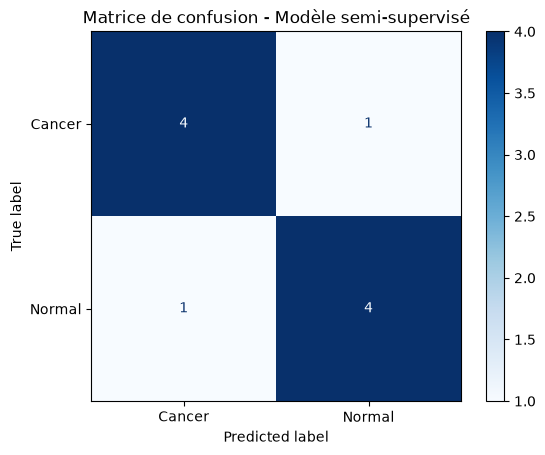

In [102]:
# Calcul de la matrice de confusion

cm_ssl = confusion_matrix(y_true_ssl,y_pred_ssl)


# Affichage

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ssl,display_labels=["Cancer","Normal"])


disp.plot(cmap="Blues")


plt.title("Matrice de confusion - Modèle semi-supervisé")


plt.show()


Le modèle détecte bien 4 cancers sur 5, seulement une image est prédite comme cancer alors qu'elles est normales, et 4 images sont bien détecté comme normales.  

Ces données sont à prendre avec un certain recul étant donné la faible dimension du dataset de validation.

### Comparaison finale des deux approches

In [103]:
# Création d'un tableau comparatif
comparaison = pd.DataFrame({"Modèle": ["Supervisé","Semi-supervisé"],"Accuracy": [accuracy,accuracy_ssl],"F1-score": [f1,f1_ssl], "Precision": [precision,precision_ssl],"Recall": [recall, recall_ssl]})

comparaison

,Modèle,Accuracy,F1-score,Precision,Recall
0,Supervisé,1.0,1.0,1.0,1.0
1,Semi-supervisé,0.8,0.8,0.8,0.8


Le modèle supervisé obtient les meilleures performances globales:  
- avec une accuracy de 100 % contre 80 % pour le modèle semi-supervisé.
- La précision est de 100 % pour le modèle supervisé, contre 80% pour le semi-supervisé.
- le rappel est de 100% pour le modèle supervisé, contre 80% pour le semi-supervisé.
- Le F1-score, qui combine précision et rappel, est également meilleur pour le modèle supervisé (100% contre 80%).


Ces données sont à prendre avec un certain recul étant donné la faible dimension du dataset de validation.

## 5- Limitation du surapprentissage

Le jeu d'entraînement étant composé d'un nombre limité d'images (80 images), le modèle présente un risque important de surapprentissage. En effet, un réseau profond tel que ResNet50 possède un grand nombre de paramètres et peut facilement mémoriser les caractéristiques spécifiques des images d'entraînement. Une augmentation de données a donc été appliquée afin d'augmenter artificiellement la diversité des exemples disponibles et d'améliorer la capacité de généralisation du modèle sur des images non vues.

In [104]:
# Nouvelle transformation avec augmentation de données

train_transform = transforms.Compose([transforms.Resize((224, 224)),
                                      transforms.RandomHorizontalFlip(p=0.5), # Augmentation de données (effectue un retournement horizontal aléatoire de l'image, p =0.5 signifie 50 % de chance d'appliquer le retournement ;50 % de chance de garder l'image originale.)
                                      transforms.RandomRotation(10), # Augmentation de données (applique une rotation aléatoire (entre -10° et 10°) de l'image.)
                                      transforms.ToTensor(),
                                      transforms.Normalize( mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

In [105]:
# On recréé le dataset d'entrainement pour qu'il prenne en compte l'augmentation de données

train_dataset_aug = BrainMRIDataset(train_paths,train_labels,transform=train_transform)

In [106]:
# Nouveaux DataLoaders pour le jeu d'entrainement augmenté

train_loader_aug = DataLoader(train_dataset_aug,batch_size=16,shuffle=True)

### Modèle supervisé

In [107]:
model_reg = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Gel des couches convolutionnelles
for param in model_reg.parameters():
    param.requires_grad = False

num_features = model_reg.fc.in_features

# Nouvelle tête sans Dropout
model_reg.fc = torch.nn.Linear(num_features, 2)

print(model_reg.fc)

Linear(in_features=2048, out_features=2, bias=True)


In [108]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_reg.parameters()),lr=0.001)

In [109]:
# Paramètres de l'early stopping

num_epochs = 30

patience = 5

best_val_loss = float("inf")

patience_counter = 0

In [110]:
# Boucle d'entraînement avec validation et early stopping

for epoch in range(num_epochs):

    # ---------- Entraînement ----------
    model_reg.train()

    running_loss = 0.0

    for images, labels in train_loader_aug:

        optimizer.zero_grad()

        outputs = model_reg(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader_aug)

    # ---------- Validation ----------
    model_reg.eval()

    validation_loss = 0.0

    with torch.no_grad():

        for images, labels in validation_loader:

            outputs = model_reg(images)

            loss = criterion(outputs, labels)

            validation_loss += loss.item()

    validation_loss /= len(validation_loader)

    print(f"Epoch {epoch+1}/{num_epochs} " 
          f"- Train Loss : {train_loss:.4f} "
          f"- Validation Loss : {validation_loss:.4f}")

    # ---------- Early stopping ----------
    if validation_loss < best_val_loss:

        best_val_loss = validation_loss

        patience_counter = 0

        torch.save(model_reg.state_dict(), "best_supervised_model.pth")

    else:

        patience_counter += 1

    if patience_counter >= patience:

        print("Early stopping déclenché.")

        break

model_reg.load_state_dict(torch.load("best_supervised_model.pth"))

Epoch 1/30 - Train Loss : 0.6449 - Validation Loss : 0.6480
Epoch 2/30 - Train Loss : 0.5659 - Validation Loss : 0.5878
Epoch 3/30 - Train Loss : 0.4650 - Validation Loss : 0.5304
Epoch 4/30 - Train Loss : 0.4050 - Validation Loss : 0.4970
Epoch 5/30 - Train Loss : 0.3783 - Validation Loss : 0.4591
Epoch 6/30 - Train Loss : 0.2998 - Validation Loss : 0.4256
Epoch 7/30 - Train Loss : 0.3422 - Validation Loss : 0.4222
Epoch 8/30 - Train Loss : 0.2500 - Validation Loss : 0.3812
Epoch 9/30 - Train Loss : 0.2378 - Validation Loss : 0.3561
Epoch 10/30 - Train Loss : 0.2285 - Validation Loss : 0.3559
Epoch 11/30 - Train Loss : 0.2440 - Validation Loss : 0.3440
Epoch 12/30 - Train Loss : 0.1895 - Validation Loss : 0.3172
Epoch 13/30 - Train Loss : 0.2021 - Validation Loss : 0.2809
Epoch 14/30 - Train Loss : 0.2087 - Validation Loss : 0.2571
Epoch 15/30 - Train Loss : 0.1817 - Validation Loss : 0.2387
Epoch 16/30 - Train Loss : 0.1712 - Validation Loss : 0.2320
Epoch 17/30 - Train Loss : 0.1750

<All keys matched successfully>

Évolution de la train loss:  

La loss d'entraînement diminue progressivement tout au long de l'apprentissage, tandis que la loss de validation diminue fortement jusqu'aux alentours de l'epoch 16, puis se stabilise et fluctue. Cette évolution peut indiquer un début de surapprentissage : le modèle continue à améliorer ses performances sur les données d'entraînement alors que le gain sur les données de validation devient limité. L'early stopping permet de limiter ce phénomène en arrêtant l'entraînement lorsque la validation loss ne s'améliore plus suffisamment. Cette observation doit toutefois être nuancée, car le jeu de validation ne contient que 10 images, ce qui peut expliquer une partie des fluctuations observées.

In [111]:
# Charger automatiquement le meilleur modèle

best_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Gel des couches convolutionnelles
for param in best_model.parameters():
    param.requires_grad = False

num_features = best_model.fc.in_features

# Même architecture que le modèle entraîné
best_model.fc = torch.nn.Linear(num_features, 2)

# Charger les meilleurs poids
best_model.load_state_dict(
    torch.load("best_supervised_model.pth")
)

# Mode évaluation
best_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [112]:
# ============================================================
# ÉVALUATION SUR LE TRAIN
# ============================================================

y_true_train = []
y_pred_train = []

best_model.eval()

with torch.no_grad():

    for images, labels in train_loader:

        outputs = best_model(images)

        predictions = torch.argmax(outputs, dim=1)

        y_true_train.extend(labels.numpy())
        y_pred_train.extend(predictions.numpy())


# ============================================================
# ÉVALUATION SUR LA VALIDATION
# ============================================================

y_true_val = []
y_pred_val = []

with torch.no_grad():

    for images, labels in validation_loader:

        outputs = best_model(images)

        predictions = torch.argmax(outputs, dim=1)

        y_true_val.extend(labels.numpy())
        y_pred_val.extend(predictions.numpy())


# ============================================================
# MÉTRIQUES
# ============================================================

train_accuracy = accuracy_score(y_true_train, y_pred_train)
train_precision = precision_score(y_true_train, y_pred_train, pos_label=0)
train_recall = recall_score(y_true_train, y_pred_train, pos_label=0)
train_f1 = f1_score(y_true_train, y_pred_train, pos_label=0)

val_accuracy = accuracy_score(y_true_val, y_pred_val)
val_precision = precision_score(y_true_val, y_pred_val, pos_label=0)
val_recall = recall_score(y_true_val, y_pred_val, pos_label=0)
val_f1 = f1_score(y_true_val, y_pred_val, pos_label=0)


# ============================================================
# AFFICHAGE
# ============================================================

comparison_results = pd.DataFrame({

    "Métrique": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Train": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ],

    "Validation": [
        val_accuracy,
        val_precision,
        val_recall,
        val_f1
    ]
})


display(
    comparison_results.style
    .format({
        "Train": "{:.4f}",
        "Validation": "{:.4f}"
    })
    .set_properties(**{
        "text-align": "center"
    })
)

,Métrique,Train,Validation
0,Accuracy,0.9750,0.9000
1,Precision,0.9750,0.8333
2,Recall,0.9750,1.0000
3,F1-score,0.9750,0.9091


Le modèle obtient un F1-score de 0,975 sur le jeu d'entraînement et de 0,91 sur le jeu de validation, soit un écart relativement faible. Ces résultats suggèrent une bonne capacité de généralisation et ne montrent pas de surapprentissage important. Le rappel atteint 1,00 sur le jeu de validation pour la classe Cancer, indiquant que l'ensemble des cas de Cancer a été correctement identifié. En revanche, la précision de 0,833 révèle la présence de quelques faux positifs.  

Dans les conditions expérimentales de cette étude, l'augmentation de données n'a pas permis d'améliorer les performances sur le jeu de validation. Elle a réduit les performances d'entraînement et l'écart entre entraînement et validation, mais cette régularisation s'est accompagnée d'une diminution du F1-score de validation.  

Ces résultats sont à prendre avec un certain recul étant donné la faible dimension du dataset de validation.

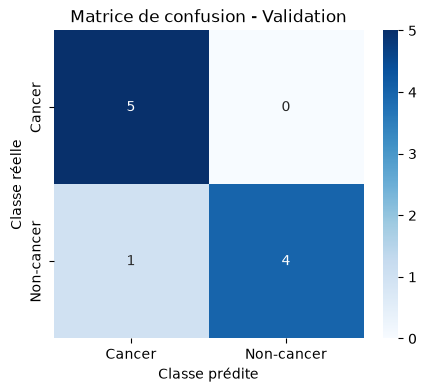

In [113]:
# ============================================================
# MATRICE DE CONFUSION - VALIDATION
# ============================================================

cm_val = confusion_matrix(
    y_true_val,
    y_pred_val
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cancer", "Non-cancer"],
    yticklabels=["Cancer", "Non-cancer"]
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion - Validation")

plt.show()

Après augmentation de données, le modèle detecte bien tous les cancer, mais pas toutes les IRM normales (1 est catégorisée comme cancer). Le modèle supervisé avec augmentation de données semble donc moins efficace que le modèle supervisé sans augmentation de données.  

Néanmoins ces résultats sont à prendre avec un certain recul étant donné la faible dimension du dataset de validation. C'est pourquoi la version avec augmentation de données a été retenue. En effet, par défaut l'augmentation de données rend le modèle plus robuste par nature (plus d'exemples).

### Modèle semi-supervisé

In [114]:
# Nouveau modèle semi-supervisé

# Chargement d'un nouveau ResNet50 pré-entraîné
model_ssl_reg = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Gel des couches convolutionnelles
for param in model_ssl_reg.parameters():
    param.requires_grad = False

# Remplacement de la couche finale
num_features = model_ssl_reg.fc.in_features

model_ssl_reg.fc = torch.nn.Linear(num_features, 2)

print(model_ssl_reg.fc)

Linear(in_features=2048, out_features=2, bias=True)


In [115]:
# Optimiseur pour l'apprentissage sur les pseudo-labels
# On entraîne uniquement la couche fc.

optimizer_ssl = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ssl_reg.parameters()),
    lr=0.001
)

In [116]:
# Entraînement sur les pseudo-labels

num_epochs_ssl = 10

model_ssl_reg.train()

for epoch in range(num_epochs_ssl):

    running_loss = 0.0

    for images, labels in unlabeled_loader:

        optimizer_ssl.zero_grad()

        outputs = model_ssl_reg(images)

        loss = criterion_ssl(outputs, labels)

        loss.backward()

        optimizer_ssl.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs_ssl} "
          f"- Loss : {running_loss/len(unlabeled_loader):.4f}")

Epoch 1/10 - Loss : 0.5130
Epoch 2/10 - Loss : 0.4018
Epoch 3/10 - Loss : 0.3673
Epoch 4/10 - Loss : 0.3447
Epoch 5/10 - Loss : 0.3346
Epoch 6/10 - Loss : 0.3270
Epoch 7/10 - Loss : 0.3039
Epoch 8/10 - Loss : 0.2910
Epoch 9/10 - Loss : 0.2882
Epoch 10/10 - Loss : 0.2839


Lors de la première phase du modèle semi-supervisé, la loss d'entraînement sur les pseudo-labels diminue progressivement, passant de 0,5130 à 0,2839 en 10 epochs. Cette diminution indique que le modèle apprend progressivement les pseudo-labels générés.

In [117]:
# Dégel de layer4 et fc

for name, param in model_ssl_reg.named_parameters():

    if "layer4" in name or "fc" in name:

        param.requires_grad = True

    else:

        param.requires_grad = False

In [118]:
# Nouvel optimiseur après le dégel de layer4 et fc

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ssl_reg.parameters()),
    lr=0.0001
)

In [119]:
# Paramètres de l'early stopping

num_epochs_ft = 30

patience = 5

best_val_loss = float("inf")

patience_counter = 0

In [120]:
# Fine-tuning avec validation et early stopping

criterion_ft = torch.nn.CrossEntropyLoss()

for epoch in range(num_epochs_ft):

    # ----- Entraînement -----
    model_ssl_reg.train()

    running_loss = 0.0

    for images, labels in train_loader_aug:

        optimizer_ft.zero_grad()

        outputs = model_ssl_reg(images)

        loss = criterion_ft(outputs, labels)

        loss.backward()

        optimizer_ft.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader_aug)

    # ----- Validation -----
    model_ssl_reg.eval()

    validation_loss = 0.0

    with torch.no_grad():

        for images, labels in validation_loader:

            outputs = model_ssl_reg(images)

            loss = criterion_ft(outputs, labels)

            validation_loss += loss.item()

    validation_loss /= len(validation_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs_ft} "
        f"- Train Loss : {train_loss:.4f} "
        f"- Validation Loss : {validation_loss:.4f}"
    )

    # ----- Early stopping -----
    if validation_loss < best_val_loss:

        best_val_loss = validation_loss

        patience_counter = 0

        torch.save(
            model_ssl_reg.state_dict(),
            "best_semisupervised_model.pth"
        )

    else:

        patience_counter += 1

    if patience_counter >= patience:

        print("Early stopping déclenché.")

        break

# Rechargement du meilleur modèle
model_ssl_reg.load_state_dict(torch.load("best_semisupervised_model.pth"))

Epoch 1/30 - Train Loss : 1.5997 - Validation Loss : 1.2331
Epoch 2/30 - Train Loss : 0.7143 - Validation Loss : 0.7143
Epoch 3/30 - Train Loss : 0.4543 - Validation Loss : 0.4371
Epoch 4/30 - Train Loss : 0.2647 - Validation Loss : 0.3108
Epoch 5/30 - Train Loss : 0.2337 - Validation Loss : 0.2583
Epoch 6/30 - Train Loss : 0.1414 - Validation Loss : 0.2323
Epoch 7/30 - Train Loss : 0.1013 - Validation Loss : 0.2278
Epoch 8/30 - Train Loss : 0.0603 - Validation Loss : 0.2063
Epoch 9/30 - Train Loss : 0.0397 - Validation Loss : 0.1900
Epoch 10/30 - Train Loss : 0.0256 - Validation Loss : 0.1913
Epoch 11/30 - Train Loss : 0.0174 - Validation Loss : 0.1622
Epoch 12/30 - Train Loss : 0.0207 - Validation Loss : 0.1480
Epoch 13/30 - Train Loss : 0.0108 - Validation Loss : 0.1618
Epoch 14/30 - Train Loss : 0.0167 - Validation Loss : 0.1635
Epoch 15/30 - Train Loss : 0.0085 - Validation Loss : 0.1655
Epoch 16/30 - Train Loss : 0.0056 - Validation Loss : 0.1671
Epoch 17/30 - Train Loss : 0.0401

<All keys matched successfully>

Lors du fine-tuning du modèle semi-supervisé avec augmentation de données, la loss d'entraînement diminue rapidement. La validation loss diminue également jusqu'à atteindre un minimum de 0,1480 à la 12ᵉ epoch. À partir de cette epoch, alors que la loss d'entraînement continue de diminuer, la validation loss augmente progressivement, indiquant un phénomène de surapprentissage. L'early stopping permet d'arrêter l'entraînement après cinq epochs sans amélioration et de conserver les poids correspondant à la meilleure performance de validation.

In [121]:
# Charger automatiquement le meilleur modèle semi-supervisé

best_model_ssl = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Gel des couches convolutionnelles
for param in best_model_ssl.parameters():
    param.requires_grad = False

num_features = best_model_ssl.fc.in_features

# Même architecture que le modèle semi-supervisé entraîné
best_model_ssl.fc = torch.nn.Linear(num_features, 2)

# Charger les meilleurs poids
best_model_ssl.load_state_dict(
    torch.load("best_semisupervised_model.pth")
)

# Mode évaluation
best_model_ssl.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [122]:
# ============================================================
# ÉVALUATION SUR LE TRAIN
# ============================================================

y_true_train_ssl = []
y_pred_train_ssl = []

best_model_ssl.eval()

with torch.no_grad():

    for images, labels in train_loader:

        outputs = best_model_ssl(images)

        predictions = torch.argmax(outputs, dim=1)

        y_true_train_ssl.extend(labels.numpy())
        y_pred_train_ssl.extend(predictions.numpy())


# ============================================================
# ÉVALUATION SUR LA VALIDATION
# ============================================================

y_true_val_ssl = []
y_pred_val_ssl = []

with torch.no_grad():

    for images, labels in validation_loader:

        outputs = best_model_ssl(images)

        predictions = torch.argmax(outputs, dim=1)

        y_true_val_ssl.extend(labels.numpy())
        y_pred_val_ssl.extend(predictions.numpy())


# ============================================================
# CALCUL DES MÉTRIQUES
# ============================================================

train_accuracy_ssl = accuracy_score(
    y_true_train_ssl,
    y_pred_train_ssl
)

train_precision_ssl = precision_score(
    y_true_train_ssl,
    y_pred_train_ssl,
    pos_label=0
)

train_recall_ssl = recall_score(
    y_true_train_ssl,
    y_pred_train_ssl,
    pos_label=0
)

train_f1_ssl = f1_score(
    y_true_train_ssl,
    y_pred_train_ssl,
    pos_label=0
)


val_accuracy_ssl = accuracy_score(
    y_true_val_ssl,
    y_pred_val_ssl
)

val_precision_ssl = precision_score(
    y_true_val_ssl,
    y_pred_val_ssl,
    pos_label=0
)

val_recall_ssl = recall_score(
    y_true_val_ssl,
    y_pred_val_ssl,
    pos_label=0
)

val_f1_ssl = f1_score(
    y_true_val_ssl,
    y_pred_val_ssl,
    pos_label=0
)


# ============================================================
# AFFICHAGE DES MÉTRIQUES
# ============================================================

comparison_ssl = pd.DataFrame({

    "Métrique": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Train": [
        train_accuracy_ssl,
        train_precision_ssl,
        train_recall_ssl,
        train_f1_ssl
    ],

    "Validation": [
        val_accuracy_ssl,
        val_precision_ssl,
        val_recall_ssl,
        val_f1_ssl
    ]
})


print("\n" + "=" * 60)
print("MODÈLE SEMI-SUPERVISÉ")
print("=" * 60)

display(
    comparison_ssl.style
    .format({
        "Train": "{:.4f}",
        "Validation": "{:.4f}"
    })
    .set_properties(**{
        "text-align": "center"
    })
)


MODÈLE SEMI-SUPERVISÉ


,Métrique,Train,Validation
0,Accuracy,1.0000,0.9000
1,Precision,1.0000,1.0000
2,Recall,1.0000,0.8000
3,F1-score,1.0000,0.8889


Le modèle semi-supervisé avec augmentation présente un surapprentissage plus marqué que le modèle supervisé avec augmentation et obtient un F1-score de validation inférieur (0,89 contre 0,909). Dans cette expérience, l'utilisation de données pseudo-étiquetées n'a donc pas permis d'améliorer la généralisation du modèle.  

Pour le modèle semi-supervisé, l'augmentation des données semble avoir amélioré les performances sur le jeu de validation. Le F1-score passe de 0,80 sans augmentation à 0,89 avec augmentation. De plus, le F1-score d'entraînement reste égal à 1,000 dans les deux cas. 

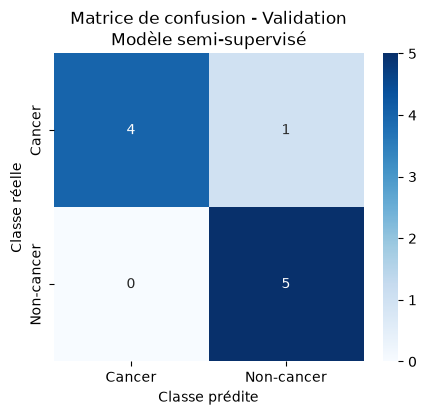

In [123]:
# ============================================================
# MATRICE DE CONFUSION - VALIDATION
# ============================================================

cm_val_ssl = confusion_matrix(
    y_true_val_ssl,
    y_pred_val_ssl
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_val_ssl,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cancer", "Non-cancer"],
    yticklabels=["Cancer", "Non-cancer"]
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion - Validation\nModèle semi-supervisé")

plt.show()

Le modèle détecte les 5 IRM normaux, et plus problématique, il ne détecte que 4 cancer sur les 5. Le modèle semi supervisé avec augmentation de données semble donc plus performant que le modèle semi supervisé sans augmentation de données.  

Néanmoins ces résultats sont à prendre avec un certain recul étant donné la faible dimension du dataset de validation. C'est pourquoi la version avec augmentation de données a été retenue. En effet, par défaut l'augmentation de données rend le modèle plus robuste par nature (plus d'exemples).

### comparaison

In [124]:
# ============================================================
# COMPARAISON DES DEUX MODÈLES AVEC AUGMENTATION
# SUR LE JEU DE VALIDATION
# ============================================================

comparison_metrics = pd.DataFrame({

    "Métrique": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Modèle supervisé + augmentation": [
        val_accuracy,
        val_precision,
        val_recall,
        val_f1
    ],

    "Modèle semi-supervisé + augmentation": [
        val_accuracy_ssl,
        val_precision_ssl,
        val_recall_ssl,
        val_f1_ssl
    ]
})


print("\n" + "=" * 70)
print("COMPARAISON DES MODÈLES AVEC AUGMENTATION - VALIDATION")
print("=" * 70)

display(
    comparison_metrics.style
    .format({
        "Modèle supervisé + augmentation": "{:.4f}",
        "Modèle semi-supervisé + augmentation": "{:.4f}"
    })
    .set_properties(**{
        "text-align": "center"
    })
)


COMPARAISON DES MODÈLES AVEC AUGMENTATION - VALIDATION


,Métrique,Modèle supervisé + augmentation,Modèle semi-supervisé + augmentation
0,Accuracy,0.9000,0.9000
1,Precision,0.8333,1.0000
2,Recall,1.0000,0.8000
3,F1-score,0.9091,0.8889


Les résultats montrent que le modèle supervisé avec augmentation de données obtient de meilleures performances sur le jeu de validation que le modèle semi-supervisé.

## 6- Optimisations des hyperparamètres

On effectue un grid-search afin d'optimiser nos deux modèles.
Par défaut, l'augmentation de données rend les modèles plus robustes par nature (plus d'exemple), on concervera donc dans la suite les modèles avec augmentation de données.
Pour la comparaison entre modèles on utilisera le F1-score, qui offre un bon compromis entre la précision et le rappel du modèle, et en cas d'égalité, on utilisera la fonction de perte qui nous permet d'évaluer si le modèle est plus ou moins confiant.

In [125]:
import copy

# ============================================================
# GRID SEARCH MANUEL - MODELE SUPERVISE
# Hyperparamètres : dropout et weight_decay
# Critère de sélection :
# 1. F1-score le plus élevé
# 2. En cas d'égalité du F1 : validation loss la plus faible
# ============================================================

# Valeurs testées
dropout_values = [0.0, 0.3, 0.5]

weight_decay_values = [0.0, 1e-4, 1e-3]


# ============================================================
# Liste pour stocker les résultats
# ============================================================

grid_results = []


# ============================================================
# Variables pour mémoriser le meilleur modèle
# ============================================================

best_f1 = 0.0
best_val_loss = float("inf")

best_dropout = None
best_weight_decay = None

best_model_state = None


# ============================================================
# Boucle sur les valeurs de dropout
# ============================================================

for dropout in dropout_values:

    # ========================================================
    # Boucle sur les valeurs de weight_decay
    # ========================================================

    for weight_decay in weight_decay_values:

        print("\n" + "=" * 60)
        print(
            f"Dropout = {dropout} | "
            f"Weight decay = {weight_decay}"
        )
        print("=" * 60)


        # ----------------------------------------------------
        # Création d'un nouveau ResNet50
        # ----------------------------------------------------

        model_grid = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )


        # ----------------------------------------------------
        # Gel de toutes les couches pré-entraînées
        # ----------------------------------------------------

        for param in model_grid.parameters():
            param.requires_grad = False


        # ----------------------------------------------------
        # Remplacement de la couche finale
        # avec Dropout + couche de classification
        # ----------------------------------------------------

        num_features = model_grid.fc.in_features

        model_grid.fc = torch.nn.Sequential(
            torch.nn.Dropout(p=dropout),
            torch.nn.Linear(num_features, 2)
        )


        # ----------------------------------------------------
        # Fonction de perte
        # ----------------------------------------------------

        criterion_grid = torch.nn.CrossEntropyLoss()


        # ----------------------------------------------------
        # Optimiseur
        # ----------------------------------------------------

        optimizer_grid = torch.optim.Adam(
            filter(
                lambda p: p.requires_grad,
                model_grid.parameters()
            ),
            lr=0.001,
            weight_decay=weight_decay
        )


        # ----------------------------------------------------
        # Entraînement
        # ----------------------------------------------------

        num_epochs_grid = 10

        model_grid.train()

        for epoch in range(num_epochs_grid):

            for images, labels in train_loader_aug:

                optimizer_grid.zero_grad()

                outputs = model_grid(images)

                loss = criterion_grid(outputs, labels)

                loss.backward()

                optimizer_grid.step()


        # ====================================================
        # EVALUATION SUR LA VALIDATION
        # ====================================================

        model_grid.eval()

        # Loss de validation
        val_loss = 0.0

        y_true_grid = []
        y_pred_grid = []


        with torch.no_grad():

            for images, labels in validation_loader:

                # Prédictions
                outputs = model_grid(images)

                # Loss
                loss = criterion_grid(outputs, labels)

                val_loss += loss.item()

                # Classe prédite
                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                # Sauvegarde
                y_true_grid.extend(
                    labels.numpy()
                )

                y_pred_grid.extend(
                    predictions.numpy()
                )


        # ----------------------------------------------------
        # Loss moyenne
        # ----------------------------------------------------

        val_loss = val_loss / len(validation_loader)


        # ----------------------------------------------------
        # Calcul du F1-score
        # pos_label=0 = Cancer
        # ----------------------------------------------------

        f1_grid = f1_score(
            y_true_grid,
            y_pred_grid,
            pos_label=0
        )


        # ----------------------------------------------------
        # Accuracy pour information
        # ----------------------------------------------------

        accuracy_grid = accuracy_score(
            y_true_grid,
            y_pred_grid
        )


        # ====================================================
        # SAUVEGARDE DES RESULTATS
        # ====================================================

        grid_results.append({
            "dropout": dropout,
            "weight_decay": weight_decay,
            "val_loss": val_loss,
            "f1": f1_grid,
            "accuracy": accuracy_grid
        })


        # ====================================================
        # AFFICHAGE
        # ====================================================

        print(
            f"Validation Loss : {val_loss:.4f}"
        )

        print(
            f"Validation F1-score : {f1_grid:.4f}"
        )

        print(
            f"Validation Accuracy : {accuracy_grid:.4f}"
        )


        # ====================================================
        # SELECTION DU MEILLEUR MODELE
        #
        # Priorité 1 : F1-score le plus élevé
        # Priorité 2 : loss la plus faible en cas d'égalité
        # ====================================================

        if (
            f1_grid > best_f1
            or
            (
                f1_grid == best_f1
                and val_loss < best_val_loss
            )
        ):

            best_f1 = f1_grid
            best_val_loss = val_loss

            best_dropout = dropout
            best_weight_decay = weight_decay

            # Sauvegarde des poids du meilleur modèle
            best_model_state = copy.deepcopy(
                model_grid.state_dict()
            )

            print(">>> Nouveau meilleur modèle")


# ============================================================
# RESULTAT FINAL DU GRID SEARCH
# ============================================================

print("\n" + "=" * 60)
print("MEILLEURE COMBINAISON")
print("=" * 60)

print(
    f"Dropout       : {best_dropout}"
)

print(
    f"Weight decay  : {best_weight_decay}"
)

print(
    f"F1-score      : {best_f1:.4f}"
)

print(
    f"Validation Loss : {best_val_loss:.4f}"
)


# ============================================================
# AFFICHAGE DE TOUS LES RESULTATS
# ============================================================

grid_results_df = pd.DataFrame(grid_results)

grid_results_df = grid_results_df.sort_values(
    by=["f1", "val_loss"],
    ascending=[False, True]
)

print(grid_results_df)


Dropout = 0.0 | Weight decay = 0.0
Validation Loss : 0.3518
Validation F1-score : 1.0000
Validation Accuracy : 1.0000
>>> Nouveau meilleur modèle

Dropout = 0.0 | Weight decay = 0.0001
Validation Loss : 0.3993
Validation F1-score : 0.7500
Validation Accuracy : 0.8000

Dropout = 0.0 | Weight decay = 0.001
Validation Loss : 0.3436
Validation F1-score : 1.0000
Validation Accuracy : 1.0000
>>> Nouveau meilleur modèle

Dropout = 0.3 | Weight decay = 0.0
Validation Loss : 0.3843
Validation F1-score : 0.9091
Validation Accuracy : 0.9000

Dropout = 0.3 | Weight decay = 0.0001
Validation Loss : 0.3723
Validation F1-score : 0.9091
Validation Accuracy : 0.9000

Dropout = 0.3 | Weight decay = 0.001
Validation Loss : 0.3453
Validation F1-score : 0.9091
Validation Accuracy : 0.9000

Dropout = 0.5 | Weight decay = 0.0
Validation Loss : 0.4182
Validation F1-score : 0.9091
Validation Accuracy : 0.9000

Dropout = 0.5 | Weight decay = 0.0001
Validation Loss : 0.3934
Validation F1-score : 1.0000
Validati

Le Grid Search montre que plusieurs configurations atteignent un F1-score de 1,000 sur le jeu de validation. Conformément au critère de sélection défini, le modèle avec un dropout de 0,0 et un weight decay de 0,001 est retenu, car il présente la plus faible validation loss parmi les configurations ayant obtenu le meilleur F1-score (0,3436). Les résultats montrent également que l'augmentation du dropout n'améliore pas systématiquement les performances dans cette expérience. Toutefois, ces résultats doivent être interprétés avec prudence, car le jeu de validation ne contient que 10 images : une seule erreur de classification peut entraîner une variation importante du F1-score.

In [126]:
# ============================================================
# GRID SEARCH MANUEL - MODÈLE SEMI-SUPERVISÉ
# Recherche de weight_decay et dropout
#
# Critère de sélection :
# 1. F1-score le plus élevé
# 2. En cas d'égalité du F1 : validation loss la plus faible
# ============================================================

import copy
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import f1_score


# ============================================================
# Valeurs des hyperparamètres à tester
# ============================================================

weight_decays = [0.0, 1e-4, 1e-3]
dropouts = [0.0, 0.3, 0.5]


# ============================================================
# Variables pour mémoriser le meilleur modèle
# ============================================================

best_f1 = 0.0
best_val_loss = float("inf")

best_weight_decay = None
best_dropout = None
best_model_ssl = None


# ============================================================
# Double boucle = Grid Search manuel
# ============================================================

for weight_decay in weight_decays:

    for dropout in dropouts:

        print("\n" + "=" * 60)
        print(
            f"Test : weight_decay={weight_decay} | "
            f"dropout={dropout}"
        )
        print("=" * 60)


        # ====================================================
        # Création d'un nouveau ResNet50 pré-entraîné
        # ====================================================

        model_grid = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )


        # ====================================================
        # Gel initial des paramètres
        # ====================================================

        for param in model_grid.parameters():
            param.requires_grad = False


        # ====================================================
        # Nouvelle couche finale avec Dropout
        # ====================================================

        num_features = model_grid.fc.in_features

        model_grid.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_features, 2)
        )


        # ====================================================
        # Fonction de perte
        # ====================================================

        criterion_grid = nn.CrossEntropyLoss()


        # ====================================================
        # PHASE 1
        # Entraînement sur les pseudo-labels
        # ====================================================

        optimizer_grid = torch.optim.Adam(
            filter(
                lambda p: p.requires_grad,
                model_grid.parameters()
            ),
            lr=0.001,
            weight_decay=weight_decay
        )


        model_grid.train()

        num_epochs_ssl_grid = 10

        for epoch in range(num_epochs_ssl_grid):

            running_loss = 0.0

            for images, labels in unlabeled_loader:

                optimizer_grid.zero_grad()

                outputs = model_grid(images)

                loss = criterion_grid(outputs, labels)

                loss.backward()

                optimizer_grid.step()

                running_loss += loss.item()


        # ====================================================
        # PHASE 2
        # Dégel de layer4 + fc
        # ====================================================

        for name, param in model_grid.named_parameters():

            if "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False


        # ====================================================
        # Nouvel optimiseur pour le fine-tuning
        # ====================================================

        optimizer_ft_grid = torch.optim.Adam(
            filter(
                lambda p: p.requires_grad,
                model_grid.parameters()
            ),
            lr=0.0001,
            weight_decay=weight_decay
        )


        # ====================================================
        # Fine-tuning sur les vrais labels
        # ====================================================

        num_epochs_ft_grid = 10

        model_grid.train()

        for epoch in range(num_epochs_ft_grid):

            running_loss = 0.0

            for images, labels in train_loader_aug:

                optimizer_ft_grid.zero_grad()

                outputs = model_grid(images)

                loss = criterion_grid(outputs, labels)

                loss.backward()

                optimizer_ft_grid.step()

                running_loss += loss.item()


        # ====================================================
        # ÉVALUATION SUR LA VALIDATION
        # ====================================================

        model_grid.eval()

        val_loss = 0.0

        y_true_grid = []
        y_pred_grid = []


        with torch.no_grad():

            for images, labels in validation_loader:

                outputs = model_grid(images)

                # Loss
                loss = criterion_grid(outputs, labels)

                val_loss += loss.item()

                # Prédictions
                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                y_true_grid.extend(
                    labels.numpy()
                )

                y_pred_grid.extend(
                    predictions.numpy()
                )


        # ====================================================
        # Loss moyenne
        # ====================================================

        val_loss = val_loss / len(validation_loader)


        # ====================================================
        # F1-SCORE DE VALIDATION
        # Classe positive = Cancer (0)
        # ====================================================

        val_f1 = f1_score(
            y_true_grid,
            y_pred_grid,
            pos_label=0
        )


        # ====================================================
        # AFFICHAGE DES RÉSULTATS
        # ====================================================

        print(
            f"Validation Loss : {val_loss:.4f}"
        )

        print(
            f"Validation F1-score : {val_f1:.4f}"
        )


        # ====================================================
        # SAUVEGARDE DU MEILLEUR MODÈLE
        #
        # Priorité 1 : F1-score le plus élevé
        # Priorité 2 : loss la plus faible en cas d'égalité
        # ====================================================

        if (
            val_f1 > best_f1
            or
            (
                val_f1 == best_f1
                and val_loss < best_val_loss
            )
        ):

            best_f1 = val_f1
            best_val_loss = val_loss

            best_weight_decay = weight_decay
            best_dropout = dropout

            best_model_ssl = copy.deepcopy(
                model_grid.state_dict()
            )

            print(">>> Nouveau meilleur modèle")


# ============================================================
# RÉSULTATS DU GRID SEARCH
# ============================================================

print("\n" + "=" * 60)
print("MEILLEURS HYPERPARAMÈTRES")
print("=" * 60)

print(
    f"Meilleur weight_decay : "
    f"{best_weight_decay}"
)

print(
    f"Meilleur dropout      : "
    f"{best_dropout}"
)

print(
    f"Meilleur F1-score     : "
    f"{best_f1:.4f}"
)

print(
    f"Meilleure Validation Loss : "
    f"{best_val_loss:.4f}"
)


Test : weight_decay=0.0 | dropout=0.0
Validation Loss : 0.1325
Validation F1-score : 0.8889
>>> Nouveau meilleur modèle

Test : weight_decay=0.0 | dropout=0.3
Validation Loss : 0.2380
Validation F1-score : 0.8000

Test : weight_decay=0.0 | dropout=0.5
Validation Loss : 0.2293
Validation F1-score : 0.8889

Test : weight_decay=0.0001 | dropout=0.0
Validation Loss : 0.1465
Validation F1-score : 1.0000
>>> Nouveau meilleur modèle

Test : weight_decay=0.0001 | dropout=0.3
Validation Loss : 0.2378
Validation F1-score : 0.8889

Test : weight_decay=0.0001 | dropout=0.5
Validation Loss : 0.2365
Validation F1-score : 0.8000

Test : weight_decay=0.001 | dropout=0.0
Validation Loss : 0.2309
Validation F1-score : 0.8889

Test : weight_decay=0.001 | dropout=0.3
Validation Loss : 0.2341
Validation F1-score : 0.8000

Test : weight_decay=0.001 | dropout=0.5
Validation Loss : 0.3471
Validation F1-score : 0.8000

MEILLEURS HYPERPARAMÈTRES
Meilleur weight_decay : 0.0001
Meilleur dropout      : 0.0
Meille

Le Grid Search du modèle semi-supervisé montre que la meilleure combinaison d'hyperparamètres est obtenue avec un dropout de 0,0 et un weight decay de 0,0001. Cette configuration atteint un F1-score de 1,000 sur le jeu de validation, associé à une validation loss de 0,1465. Les configurations intégrant un dropout de 0,3 ou 0,5 obtiennent globalement des F1-scores inférieurs, ce qui ne met pas en évidence de bénéfice du dropout dans cette expérience. Ces résultats doivent toutefois être interprétés avec prudence, car le jeu de validation ne contient que 10 images. Le F1-score de 1,000 signifie que le modèle n'a commis aucune erreur sur ces images, mais ne garantit pas une généralisation parfaite à de nouvelles données.

## 7- Choix du meilleur modèle et Vérification finale des performances des modèles sur le jeu de test

Pour la comparaison finale entre modèles on utilisera le F1-score, qui offre un bon compromis entre la précision et le rappel du modèle.

In [128]:
# ============================================================
# COMPARAISON FINALE DES DEUX MEILLEURS MODÈLES
# ============================================================


# ============================================================
# 1. RECONSTRUCTION DU MEILLEUR MODÈLE SUPERVISÉ
# ============================================================

best_supervised = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Gel des couches pré-entraînées
for param in best_supervised.parameters():
    param.requires_grad = False

# Meilleur dropout trouvé par le Grid Search
num_features = best_supervised.fc.in_features

best_supervised.fc = nn.Sequential(nn.Dropout(p=0.0), nn.Linear(num_features, 2))

# Charge les poids du meilleur modèle, entraîné avec le meilleur weight_decay
best_supervised.load_state_dict(best_model_state)

# Mode évaluation
best_supervised.eval()


# ============================================================
# 2. RECONSTRUCTION DU MEILLEUR MODÈLE SEMI-SUPERVISÉ
# ============================================================

best_semisupervised = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Gel initial des couches pré-entraînées
for param in best_semisupervised.parameters():
    param.requires_grad = False

# Meilleur dropout trouvé par le Grid Search
num_features = best_semisupervised.fc.in_features

best_semisupervised.fc = nn.Sequential(nn.Dropout(p=0.0), nn.Linear(num_features, 2))

# Dégel de layer4 + fc
for name, param in best_semisupervised.named_parameters():

    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# # Charge les poids du meilleur modèle, entraîné avec le meilleur weight_decay
best_semisupervised.load_state_dict(best_model_ssl)

# Mode évaluation
best_semisupervised.eval()


# ============================================================
# 3. FONCTION D'ÉVALUATION
# ============================================================

criterion_test = nn.CrossEntropyLoss()


def evaluate_model(model, data_loader):

    y_true = []
    y_pred = []

    total_loss = 0.0

    with torch.no_grad():

        for images, labels in data_loader:

            # Prédictions
            outputs = model(images)

            # Calcul de la loss
            loss = criterion_test(outputs, labels)

            total_loss += loss.item()

            # Classe prédite
            predictions = torch.argmax(outputs, dim=1)

            # Sauvegarde des résultats
            y_true.extend(labels.numpy())
            y_pred.extend(predictions.numpy())

    # Loss moyenne
    loss = total_loss / len(data_loader)

    # Calcul des métriques
    accuracy = accuracy_score(y_true,y_pred)

    precision = precision_score(y_true,y_pred,pos_label=0)

    recall = recall_score(y_true,y_pred,pos_label=0)

    f1 = f1_score(y_true,y_pred,pos_label=0)

    return loss, accuracy, precision, recall, f1


# ============================================================
# 4. ÉVALUATION DU MODÈLE SUPERVISÉ
# ============================================================

train_results_supervised = evaluate_model(best_supervised, train_loader)

validation_results_supervised = evaluate_model(best_supervised, validation_loader)

test_results_supervised = evaluate_model(best_supervised, test_loader)


# ============================================================
# 5. ÉVALUATION DU MODÈLE SEMI-SUPERVISÉ
# ============================================================

train_results_ssl = evaluate_model(best_semisupervised, train_loader)

validation_results_ssl = evaluate_model(best_semisupervised, validation_loader)

test_results_ssl = evaluate_model(best_semisupervised, test_loader)


# ============================================================
# 6. RÉSULTATS DU MODÈLE SUPERVISÉ
# ============================================================

supervised_results = pd.DataFrame({"Métrique": ["Loss","Accuracy","Precision","Recall","F1-score"],"Train": train_results_supervised,"Validation": validation_results_supervised,"Test": test_results_supervised})


print("\n" + "=" * 60)
print("MODÈLE SUPERVISÉ")
print("=" * 60)

display(supervised_results.style.format({"Train": "{:.4f}","Validation": "{:.4f}","Test": "{:.4f}"}).set_properties(**{"text-align": "center"}))


# ============================================================
# 7. RÉSULTATS DU MODÈLE SEMI-SUPERVISÉ
# ============================================================

ssl_results = pd.DataFrame({"Métrique": ["Loss","Accuracy","Precision","Recall","F1-score"],"Train": train_results_ssl,"Validation": validation_results_ssl,"Test": test_results_ssl})


print("\n" + "=" * 60)
print("MODÈLE SEMI-SUPERVISÉ")
print("=" * 60)

display(ssl_results.style.format({"Train": "{:.4f}","Validation": "{:.4f}","Test": "{:.4f}"}).set_properties(**{"text-align": "center"}))


# ============================================================
# 8. COMPARAISON FINALE SUR LE JEU DE TEST
# ============================================================

comparison_test = pd.DataFrame({"Métrique": ["Loss","Accuracy","Precision","Recall","F1-score"], "Modèle supervisé": test_results_supervised,"Modèle semi-supervisé": test_results_ssl})


print("\n" + "=" * 60)
print("COMPARAISON FINALE - JEU DE TEST")
print("=" * 60)

display(comparison_test.style.format({"Modèle supervisé": "{:.4f}","Modèle semi-supervisé": "{:.4f}"}).set_properties(**{"text-align": "center"}))


# ============================================================
# 9. CHOIX FINAL DU MEILLEUR MODÈLE SUR LE JEU DE VALIDATION
#
# Le choix du modèle est effectué sur le jeu de validation.
# Le jeu de test sert uniquement à évaluer les performances
# finales des modèles.
#
# Critère 1 : F1-score le plus élevé
# Critère 2 : en cas d'égalité du F1, loss la plus faible
# ============================================================

val_loss_supervised = validation_results_supervised[0]
val_f1_supervised = validation_results_supervised[4]

val_loss_ssl = validation_results_ssl[0]
val_f1_ssl = validation_results_ssl[4]


print("\n" + "=" * 60)
print("CHOIX FINAL DU MEILLEUR MODÈLE")
print("=" * 60)

print(f"Validation - Supervisé      : "
      f"F1 = {val_f1_supervised:.4f} | "
      f"Loss = {val_loss_supervised:.4f}")

print(f"Validation - Semi-supervisé : "
      f"F1 = {val_f1_ssl:.4f} | "
      f"Loss = {val_loss_ssl:.4f}")


# ============================================================
# Sélection sur le jeu de validation :
# 1. F1 le plus élevé
# 2. Si égalité du F1 → Loss la plus faible
# ============================================================

if (val_f1_supervised > val_f1_ssl or (val_f1_supervised == val_f1_ssl and val_loss_supervised < val_loss_ssl)):

    best_final_model = best_supervised

    print("\n→ Le modèle supervisé est retenu.")


elif (val_f1_ssl > val_f1_supervised or (val_f1_ssl == val_f1_supervised and val_loss_ssl < val_loss_supervised)):

    best_final_model = best_semisupervised

    print("\n→ Le modèle semi-supervisé est retenu.")


else:

    print("\n→ Les deux modèles ont le même F1-score "
          "et la même loss sur le jeu de validation.")


MODÈLE SUPERVISÉ


,Métrique,Train,Validation,Test
0,Loss,0.2613,0.3436,0.3337
1,Accuracy,0.9875,1.0000,0.9000
2,Precision,0.9756,1.0000,0.8333
3,Recall,1.0000,1.0000,1.0000
4,F1-score,0.9877,1.0000,0.9091



MODÈLE SEMI-SUPERVISÉ


,Métrique,Train,Validation,Test
0,Loss,0.0108,0.1465,0.4506
1,Accuracy,1.0000,1.0000,0.9000
2,Precision,1.0000,1.0000,0.8333
3,Recall,1.0000,1.0000,1.0000
4,F1-score,1.0000,1.0000,0.9091



COMPARAISON FINALE - JEU DE TEST


,Métrique,Modèle supervisé,Modèle semi-supervisé
0,Loss,0.3337,0.4506
1,Accuracy,0.9000,0.9000
2,Precision,0.8333,0.8333
3,Recall,1.0000,1.0000
4,F1-score,0.9091,0.9091



CHOIX FINAL DU MEILLEUR MODÈLE
Validation - Supervisé      : F1 = 1.0000 | Loss = 0.3436
Validation - Semi-supervisé : F1 = 1.0000 | Loss = 0.1465

→ Le modèle semi-supervisé est retenu.


Le choix du modèle final est effectué à partir du jeu de validation, conformément à la méthodologie définie. Les deux approches obtiennent un F1-score de 1,000 sur la validation. Elles sont donc départagées par la validation loss, plus faible pour le modèle semi-supervisé (0,1465 contre 0,3436), qui est ainsi retenu.  


L'évaluation finale sur le jeu de test montre que les deux modèles obtiennent les mêmes performances en termes d'accuracy, de précision, de rappel et de F1-score (respectivement 0,900, 0,833, 1,000 et 0,909). Le modèle semi-supervisé n'apporte donc pas de gain de performance en classification sur le jeu de test dans cette expérience. Ces résultats doivent toutefois être interprétés avec prudence compte tenu de la taille limitée des jeux de données, notamment du jeu de validation composé de seulement 10 images.

## 8- Conclusion

Dans cette expérimentation, l'ajout des données faiblement labellisées n'a pas permis d'améliorer le F1-score du modèle supervisé : les deux approches obtiennent un F1-score identique de 0,9091 sur le jeu de test. Sur le jeu de validation, les deux modèles obtiennent également un F1-score de 1,0000. Ils sont donc départagés selon le second critère de sélection, à savoir la validation loss. Le modèle semi-supervisé présente une validation loss plus faible (0,1465 contre 0,3436) et est ainsi retenu comme modèle final.

L'évaluation sur le jeu de test montre toutefois que les deux modèles obtiennent exactement les mêmes performances en termes d'accuracy (0,9000), de précision (0,8333), de rappel (1,0000) et de F1-score (0,9091). La loss sur le test est en revanche plus élevée pour le modèle semi-supervisé (0,4506 contre 0,3337). Ainsi, dans cette expérimentation, l'utilisation des données faiblement labellisées n'a pas apporté de gain mesurable en termes de F1-score sur les données de test.

La qualité des pseudo-labels reste toutefois un élément important à prendre en compte. En effet, le score ARI d'environ 0,15 obtenu avec K-Means montre une correspondance limitée entre les groupes identifiés et les vraies classes. Les pseudo-labels générés peuvent donc contenir des erreurs susceptibles de limiter le bénéfice apporté par les données supplémentaires.

Enfin, ces résultats doivent être interprétés avec prudence compte tenu de la taille limitée des jeux de données, notamment du jeu de validation qui ne contient que 10 images. Le faible nombre d'observations peut rendre les métriques sensibles à la composition de l'échantillon et ne permet pas de conclure de manière définitive à la supériorité d'une approche. Dans cette expérimentation, le modèle semi-supervisé est néanmoins retenu comme modèle final, conformément au protocole de sélection défini : les deux modèles ayant obtenu le même F1-score sur la validation, le modèle semi-supervisé a été sélectionné grâce à sa validation loss plus faible.